# **[AI 221] FINAL PROJECT**
**PRISM: Property Representation and Interpretable Structural Mapper**

by Misael Maningo

(Python 3.12.13)

# Imports

## Standard Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns

import random
import math
import subprocess
from IPython.display import display, Image
from collections.abc import Callable

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, auc, matthews_corrcoef
from sklearn.manifold import TSNE

## Special Imports

In [4]:
from tqdm import tqdm
from scipy import stats
import optuna
import plotly

optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/misael.andre.maningo/.conda/envs/misael-ML-1-12-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## RDKit

In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem, MolFromSmiles, AddHs, Descriptors
from rdkit.Chem.Draw import SimilarityMaps, rdMolDraw2D

## Torch

In [6]:
import torch
import torch.nn as nn
from torch_geometric.data import Data
import torch.nn.functional as F
from torch.nn import Linear, BatchNorm1d, Dropout

from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader

import torch_scatter

## Captum

In [7]:
from captum.attr import IntegratedGradients, ShapleyValueSampling

## Scikit fingerprints

In [8]:
from skfp.model_selection.splitters import scaffold_train_valid_test_split

## Important Constants

In [9]:
RANDOM_STATE = 42

## Other Functions

In [10]:
def get_cuda_device() -> torch.device:
    if not torch.cuda.is_available():
        print("CUDA is not available on this system. Falling back to CPU.")
        return torch.device('cpu')
    
    cmd = "nvidia-smi --query-gpu=index,name,utilization.gpu,memory.used,memory.total --format=csv,noheader | awk -F, '$3+0 < 50'"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout.strip()
    
    if not output:
        print("No GPUs found with < 50% utilization.")
        choice = input("Enter a CUDA device index manually (e.g., 0): ").strip()
        gpu_id = int(choice) if choice.isdigit() else 0
        return torch.device(f'cuda:{gpu_id}')
    
    print("Available GPUs (< 50% utilization):")
    print("-" * 60)
    print(output)
    print("-" * 60)
    
    valid_indices = [line.split(',')[0].strip() for line in output.split('\n') if line]
    
    while True:
        choice = input(f"Enter the CUDA device number to use {valid_indices}: ").strip()
        
        if choice in valid_indices:
            print(f"Successfully selected cuda:{choice}")
            return torch.device(f'cuda:{choice}')
        else:
            print(f"Invalid choice '{choice}'. Please pick from {valid_indices}.")

# Dataset

## Downloading

### SangsterLogP

In [102]:
sangsterlogP = pd.read_excel("SangsterLogP.xlsx", sheet_name=0)

print(f"Total number of molecules in imported dataset: {len(sangsterlogP.index):,}")
display(sangsterlogP)

Total number of molecules in imported dataset: 23,520


,ID,SMILES,Name,CASRN,Lipophilicity,pH,ΔDP,Ionisation-based class,logP,Adj pH,Temperature,Exp Method,Recommended,Lipinski descriptors,bRo5?,Source
0,R1,NC1=C(CO)C2=NC3=CC=CC=C3C=C2C=C1,NaN,NaN,1.77,7.4,< 0.3,N,1.77,NaN,NaN,NaN,NaN,224.3;2.5;2;3,0,DOI: 10.1021/jm020389w | PMID: 12620073
1,R2,CNC1=C(CO)C2=NC3=CC=CC=C3C=C2C=C1,NaN,NaN,2.1,7.4,< 0.3,N,2.1,NaN,NaN,NaN,NaN,238.3;2.9;2;3,0,DOI: 10.1021/jm020389w | PMID: 12620073
2,R3,CN(C)C1=C(CO)C2=NC3=C(C=CC=C3)C=C2C=C1,NaN,NaN,2.2,7.4,< 0.3,N,2.2,NaN,NaN,NaN,NaN,252.3;2.9;1;3,0,DOI: 10.1021/jm020389w | PMID: 12620073
3,R4,O=C1NC2=C(CO1)C1=C(C=C2)C=C2C=CC=CC2=N1,NaN,NaN,1.64,7.4,< 0.3,N,1.64,NaN,22.0,SF-AS,NaN,250.3;3.5;1;3,0,DOI: 10.1021/jm020389w | PMID: 12620073
4,R5,CN(C1=CC2=NC3=C(C=CC4=C3COCN4)C=C2C=C1)S(C)(=O)=O,NaN,NaN,1.54,NaN,NaN,P,1.54,NaN,NaN,NaN,NaN,343.4;2.7;1;5,0,DOI: 10.1021/jm020389w | PMID: 12620073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23515,R59815644,C[C@@H](CNC(=O)C1=C(O)C(O)=CC2=C(O)C(=C(C)C=C1...,CHEMBL1094250,NaN,3.48,7.4,NaN,NC (>700Da),3.48,NaN,NaN,NaN,NaN,700.8;7.6;8;8,1,DOI: 10.6019/chembl3301361
23516,R59816324,CC(=O)O[C@@]12CO[C@@H]1C[C@H](O)[C@]1(C)[C@@H]...,CHEMBL92,NaN,3.4,7.4,NaN,NC (>700Da),3.4,NaN,NaN,NaN,NaN,807.9;3.4;4;14,1,DOI: 10.6019/chembl3301361
23517,R59817149,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,NaN,NaN,3.46,11,NaN,NC (>700Da),3.46,NaN,NaN,NaN,NaN,837.1;2.2;5;17,1,DOI: 10.6019/chembl3301361
23518,R59823013,CC1(C)CCC(=C(CN2CCN(CC2)C2=CC=C(C=C2)C(=O)NS(=...,NaN,NaN,0.98,11,NaN,NC (>700Da),0.98,NaN,NaN,NaN,NaN,974.6;8.8;2;11,1,DOI: 10.6019/chembl3301361


Cleaning logP column.

In [103]:
sangsterlogP['logP'] = (
    sangsterlogP['logP']
    .astype(str)
    .str.extract(r'^(-?[0-9.]+)')
    .astype(float)
)

In [11]:
sangsterlogP.describe()

,logP,Adj pH,Temperature,bRo5?
count,23520.000000,1343.000000,5025.000000,23520.000000
mean,2.397478,8.014743,24.972338,0.034524
std,1.703444,4.011997,4.472963,0.182574
min,-3.760000,0.000000,0.000000,0.000000
25%,1.260000,4.000000,23.000000,0.000000
50%,2.360000,9.000000,25.000000,0.000000
75%,3.410000,11.500000,25.000000,0.000000
max,11.710000,14.000000,60.000000,1.000000


In [104]:
smiles_dataset = sangsterlogP['SMILES']
logp_dataset = sangsterlogP['logP']

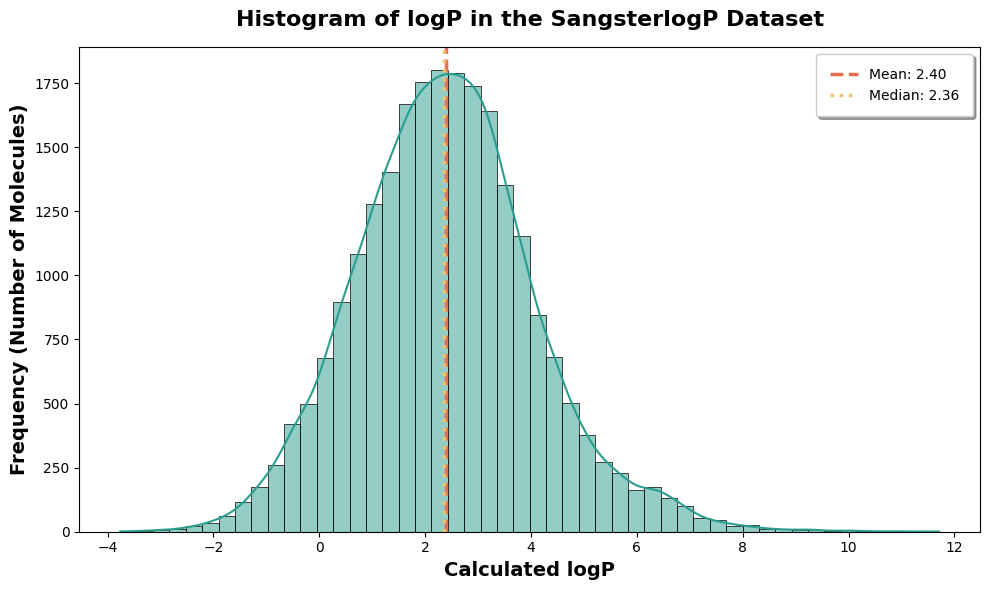

In [13]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=sangsterlogP, 
    x='logP', 
    bins=50, 
    kde=True, 
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.5
)

mean_val = sangsterlogP['logP'].mean()
median_val = sangsterlogP['logP'].median()

plt.axvline(mean_val, color='#E76F51', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#E9C46A', linestyle=':', linewidth=2.5, 
            label=f'Median: {median_val:.2f}')

plt.title('Histogram of logP in the SangsterlogP Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Calculated logP', fontsize=14, fontweight='bold')
plt.ylabel('Frequency (Number of Molecules)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()

### ZINC 250k

In [11]:
# DATASET_URL = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
DATASET_URL = "/home/misael.andre.maningo/MEng AI/AI 221/ZINC_250k.csv"  # Local path
zinc = pd.read_csv(DATASET_URL)
zinc["smiles"] = zinc["smiles"].apply(lambda s: s.replace("\n", ""))

print(f"Total number of molecules in imported dataset: {len(zinc.index):,}")
display(zinc)

Total number of molecules in imported dataset: 249,455


,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182
...,...,...,...,...
249450,CC1(C)CC[C@H](CNC(=O)Cn2ncc3ccccc3c2=O)c2ccccc21,3.36790,0.745901,2.900726
249451,Cn1ccnc1C(=O)c1ccc(NC(=O)C2CCN(C(=O)C(C)(C)C)C...,2.87430,0.799426,2.326627
249452,Cc1ccc(NC(=O)C(=O)N(C)Cc2ccccc2)c(C)c1,2.90054,0.878086,1.840642
249453,Cc1cc(C(=O)Nc2ccc(OCC(N)=O)cc2)c(C)n1C1CC1,2.55624,0.852917,2.024638


In [87]:
zinc.describe()

,logP,qed,SAS
count,249455.000000,249455.000000,249455.000000
mean,2.457093,0.728264,3.053235
std,1.434330,0.139565,0.834796
min,-6.876200,0.111811,1.132738
25%,1.574810,0.645872,2.416627
50%,2.605600,0.759878,2.892993
75%,3.486760,0.835714,3.545533
max,8.252100,0.947882,7.289283


In [12]:
smiles_dataset = zinc['smiles']
logp_dataset = zinc['logP']

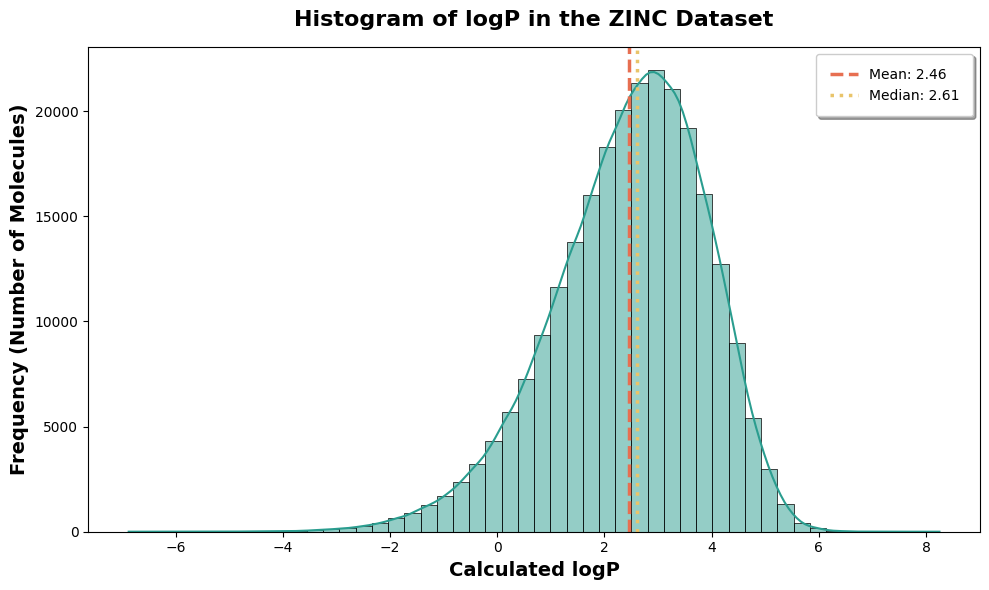

In [163]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=zinc, 
    x='logP', 
    bins=50, 
    kde=True, 
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.5
)

mean_val = zinc['logP'].mean()
median_val = zinc['logP'].median()

plt.axvline(mean_val, color='#E76F51', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#E9C46A', linestyle=':', linewidth=2.5, 
            label=f'Median: {median_val:.2f}')

plt.title('Histogram of logP in the ZINC Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Calculated logP', fontsize=14, fontweight='bold')
plt.ylabel('Frequency (Number of Molecules)', fontsize=14, fontweight='bold')

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()

## Conversion

In [13]:
def DataFromSmiles(
    smiles: str, target_logp: float | None = None
) -> Data:
    mol = MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("SMILES corresponds to an empty molecule.") 
    mol = AddHs(mol)
    
    AllChem.ComputeGasteigerCharges(mol)  # type: ignore
    
    # Node features
    node_features: list[list[float]] = []
    for atom in mol.GetAtoms():
        atom_feature_vector = [
            atom.GetAtomicNum(),
            
            atom.GetDegree(),
            atom.GetTotalNumHs(),
            atom.GetTotalValence(),
            atom.GetFormalCharge(),
            float(atom.GetProp('_GasteigerCharge')),
            
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            int(atom.GetChiralTag()),
            
            # other chemical features
        ]
        node_features.append(atom_feature_vector)
    x = torch.tensor(node_features, dtype=torch.float)
    
    # Edge features
    src_nodes = []
    dst_nodes = []
    edge_features: list[list[float]] = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        
        src_nodes.extend([i, j])
        dst_nodes.extend([j, i])
        
        bond_feature_vector = [
            bond.GetBondTypeAsDouble(), # bond type
            int(bond.GetStereo()),      # stereochemistry
            int(bond.GetIsConjugated()) # conjugation state
        ]
        
        edge_features.extend([bond_feature_vector, bond_feature_vector])
        
    edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)
    edge_attr = torch.tensor(edge_features, dtype=torch.float)
    
    # Target 
    if target_logp is not None:
        y = torch.tensor([target_logp], dtype=torch.float)
    else:
        y = None
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [14]:
data_dataset = []
valid_positions = []

for pos, (smiles, logP) in enumerate(tqdm(zip(smiles_dataset, logp_dataset), total=len(smiles_dataset))):
    data = DataFromSmiles(smiles, logP)

    is_corrupted = False
    if data is None:
        is_corrupted = True
    elif math.isnan(data.y.item()) or math.isinf(data.y.item()): # type: ignore
        is_corrupted = True
    elif torch.isnan(data.x).any() or torch.isinf(data.x).any(): # type: ignore
        is_corrupted = True
    elif getattr(data, 'edge_attr', None) is not None:
        if torch.isnan(data.edge_attr).any() or torch.isinf(data.edge_attr).any(): # type: ignore
            is_corrupted = True
            
    if not is_corrupted:
        data_dataset.append(data)
        valid_positions.append(pos)

print(f"Final size: {len(data_dataset):,}")

smiles_dataset = smiles_dataset.iloc[valid_positions].reset_index(drop=True) # type: ignore
logp_dataset = logp_dataset.iloc[valid_positions].reset_index(drop=True) # type: ignore

100%|██████████| 249455/249455 [05:36<00:00, 740.27it/s]

Final size: 249,453


In [15]:
dataset_num_node_features = data_dataset[0].x.shape[1]
dataset_num_edge_features = data_dataset[0].edge_attr.shape[1]

print(f"Number of node features: {dataset_num_node_features}")
print(f"Number of edge features: {dataset_num_edge_features}")

Number of node features: 10
Number of edge features: 3


# Train-Test Split

## Random Splitting

In [93]:
data_idx = np.arange(len(data_dataset))

train_idx, test_idx = train_test_split(
    data_idx, test_size=0.2, random_state=RANDOM_STATE
)

train_idx, val_idx = train_test_split(
    train_idx, test_size=0.125, random_state=RANDOM_STATE
)

## Scaffold Splitting

In [16]:
train_idx, val_idx, test_idx = scaffold_train_valid_test_split( # type: ignore
    smiles_dataset, train_size=0.7, valid_size=0.1, test_size=0.2, return_indices=True # type: ignore
)

## Slicing

In [17]:
assert len(data_dataset) == len(smiles_dataset) == len(logp_dataset), "Not equal lengths"

train_data = [data_dataset[i] for i in train_idx]
val_data   = [data_dataset[i] for i in val_idx]
test_data  = [data_dataset[i] for i in test_idx]

train_smiles = [smiles_dataset[i] for i in train_idx]
val_smiles   = [smiles_dataset[i] for i in val_idx]
test_smiles  = [smiles_dataset[i] for i in test_idx]

train_logp = [logp_dataset[i] for i in train_idx]
val_logp   = [logp_dataset[i] for i in val_idx]
test_logp  = [logp_dataset[i] for i in test_idx]

In [18]:
print(f"Train size: {len(train_idx)}")
print(f"Val size:   {len(val_idx)}")
print(f"Test size:  {len(test_idx)}")

Train size: 174618
Val size:   24945
Test size:  49890


## Train-Test Evaluation

In [100]:
train_props = np.zeros((6, len(train_idx)))
for i, smiles in enumerate(train_smiles):
    mol = Chem.MolFromSmiles(smiles)
    train_props[0, i] = train_logp[i]
    train_props[1, i] = Descriptors.MolWt(mol)  # type: ignore
    train_props[2, i] = Descriptors.NumHAcceptors(mol) # type: ignore
    train_props[3, i] = Descriptors.TPSA(mol) # type: ignore
    train_props[4, i] = Descriptors.NumHDonors(mol) # type: ignore
    train_props[5, i] = Descriptors.NumRotatableBonds(mol) # type: ignore

val_props = np.zeros((6, len(val_idx)))
for i, smiles in enumerate(val_smiles):
    mol = Chem.MolFromSmiles(smiles)
    val_props[0, i] = val_logp[i]
    val_props[1, i] = Descriptors.MolWt(mol) # type: ignore
    val_props[2, i] = Descriptors.NumHAcceptors(mol) # type: ignore
    val_props[3, i] = Descriptors.TPSA(mol) # type: ignore
    val_props[4, i] = Descriptors.NumHDonors(mol) # type: ignore
    val_props[5, i] = Descriptors.NumRotatableBonds(mol) # type: ignore
    
test_props = np.zeros((6, len(test_idx)))
for i, smiles in enumerate(test_smiles):
    mol = Chem.MolFromSmiles(smiles)
    test_props[0, i] = test_logp[i]
    test_props[1, i] = Descriptors.MolWt(mol) # type: ignore
    test_props[2, i] = Descriptors.NumHAcceptors(mol) # type: ignore
    test_props[3, i] = Descriptors.TPSA(mol) # type: ignore
    test_props[4, i] = Descriptors.NumHDonors(mol) # type: ignore
    test_props[5, i] = Descriptors.NumRotatableBonds(mol) # type: ignore

### KDE Plot

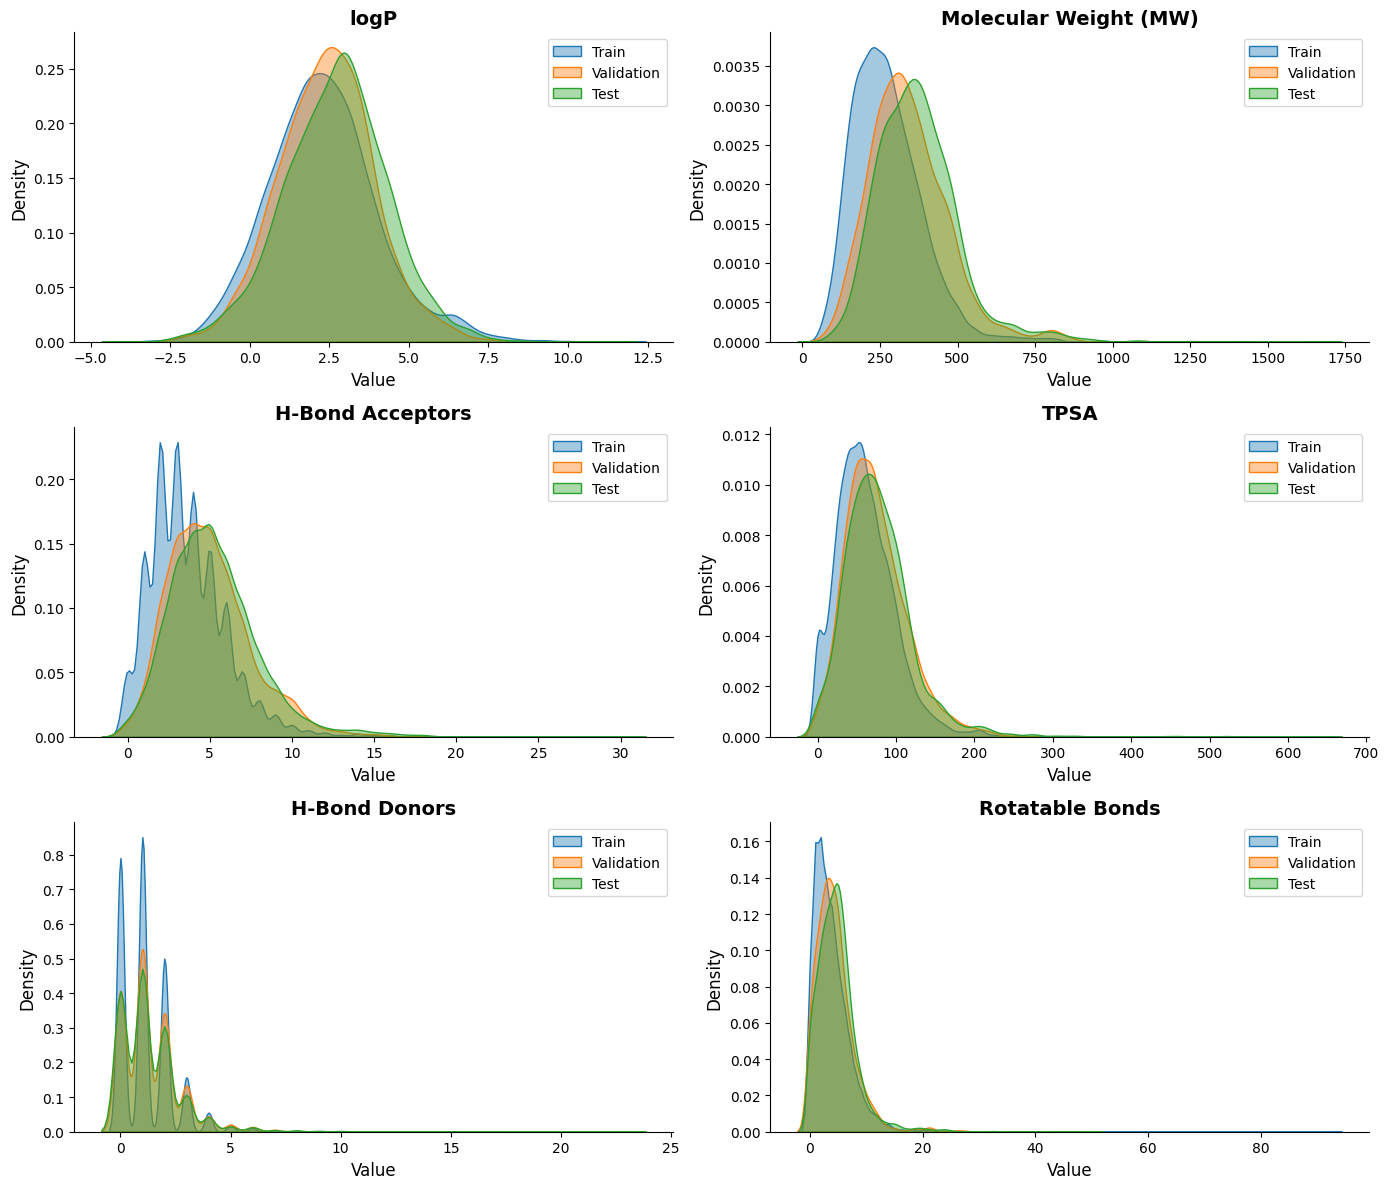

In [225]:
property_names = [
    "logP", 
    "Molecular Weight (MW)", 
    "H-Bond Acceptors", 
    "TPSA", 
    "H-Bond Donors", 
    "Rotatable Bonds"
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    
    sns.kdeplot(train_props[i], fill=True, label="Train", ax=ax, alpha=0.4)
    sns.kdeplot(val_props[i], fill=True, label="Validation", ax=ax, alpha=0.4)
    sns.kdeplot(test_props[i], fill=True, label="Test", ax=ax, alpha=0.4)
    
    ax.set_title(property_names[i], fontsize=14, fontweight='bold')
    ax.set_xlabel("Value", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### t-SNE

In [101]:
X_train = train_props.T
X_val = val_props.T
X_test = test_props.T
X_all = np.vstack([X_train, X_val, X_test])
X_scaled = StandardScaler().fit_transform(X_all)

labels = (
    ['Train'] * len(X_train) + 
    ['Validation'] * len(X_val) + 
    ['Test'] * len(X_test)
)

tsne = TSNE(
    n_components=2,
    perplexity=50.0,
    random_state=RANDOM_STATE,
)
tsne_results = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_tsne['Dataset Split'] = labels

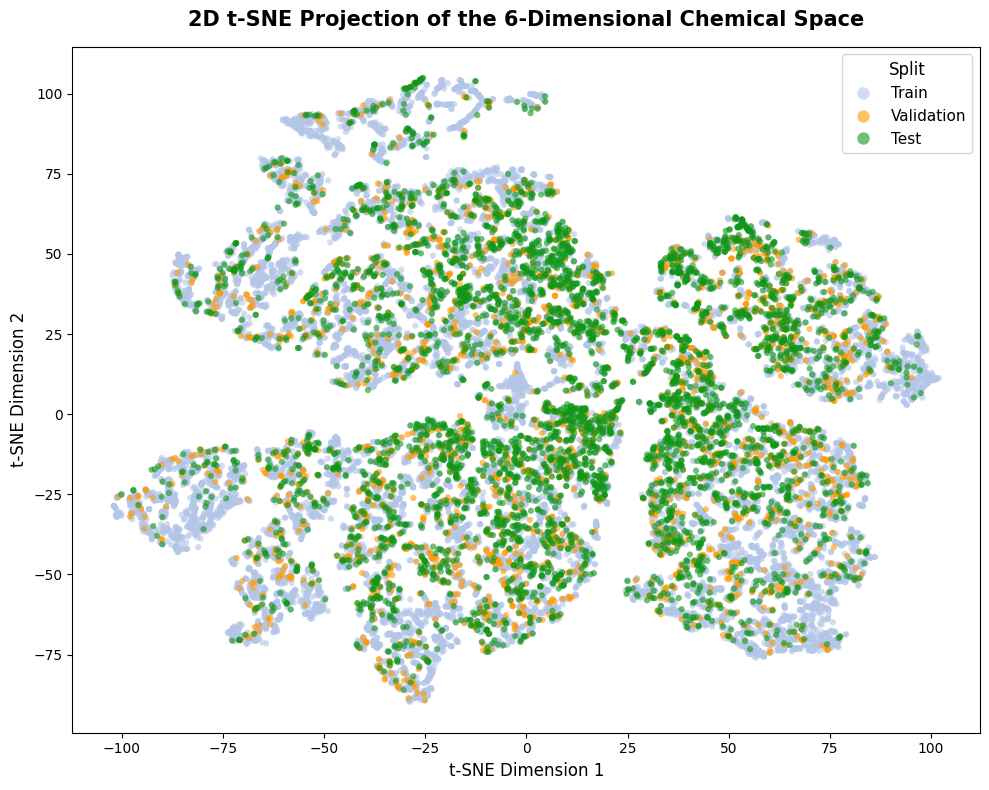

In [102]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='tsne_1',
    y='tsne_2',
    hue='Dataset Split',
    hue_order=['Train', 'Validation', 'Test'],
    palette={'Train': '#B4C6E7', 'Validation': '#FF9900', 'Test': '#109618'},
    data=df_tsne,
    alpha=0.6,
    s=20,
    edgecolor='none'
)

plt.title('2D t-SNE Projection of the 6-Dimensional Chemical Space', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

plt.legend(title='Split', markerscale=2, fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

### Statistical Test

In [265]:
for i in range(6):
    property_name = property_names[i]
    t_stat, p_value = stats.ttest_ind(train_props[i], test_props[i], equal_var=False)
    print(f"{property_name}: {p_value:.4e}", end="\t")
    
    if p_value < 0.05:  # type: ignore
        print("Reject null: The sets are statistically different.")
    else:
        print(f"Do not reject null: Not enough evidence to conclude a difference.")

logP: 7.9635e-49	Reject null: The sets are statistically different.
Molecular Weight (MW): 0.0000e+00	Reject null: The sets are statistically different.
H-Bond Acceptors: 1.6761e-260	Reject null: The sets are statistically different.
TPSA: 3.1029e-112	Reject null: The sets are statistically different.
H-Bond Donors: 1.5848e-19	Reject null: The sets are statistically different.
Rotatable Bonds: 1.5782e-63	Reject null: The sets are statistically different.


# Model Class

In [19]:
class LogPGNN(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        num_edge_features: int,
        hidden_channels: int = 64,
        num_conv: int = 3,
        heads: int = 4,
        funnel_dim: int = 32
    ):
        super(LogPGNN, self).__init__()
        
        self.conv_list = nn.ModuleList()
        self.bn_list = nn.ModuleList()
        
        # Layer 1
        self.conv_list.append(
            GATv2Conv(
                in_channels=num_node_features,
                out_channels=hidden_channels,
                heads=heads,
                concat=False,
                edge_dim=num_edge_features
            )
        )
        self.bn_list.append(BatchNorm1d(hidden_channels))
        
        # Layer 2 to num_conv
        for _ in range(1, num_conv):
            self.conv_list.append(
                GATv2Conv(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    heads=heads,
                    concat=False,
                    edge_dim=num_edge_features
                )
            )
            self.bn_list.append(BatchNorm1d(hidden_channels))
        
        self.lin1 = Linear(hidden_channels * 2, hidden_channels)
        self.lin2 = Linear(hidden_channels, funnel_dim)
        self.lin3 = Linear(funnel_dim, 1)
        
        self.dropout = Dropout(p=0.3)
    

    def forward(
        self, x, edge_index, edge_attr, batch, return_attention: bool = False
    ):
        
        for i in range(len(self.conv_list)):
            x_prev = x
            
            is_last_layer = (i == len(self.conv_list) - 1)
            if return_attention and is_last_layer:
                x, (attn_edge_index, attn_weights) = self.conv_list[i](
                    x, edge_index, edge_attr=edge_attr, return_attention_weights=True
                )
            else:
                x = self.conv_list[i](x, edge_index, edge_attr=edge_attr)
            
            x = self.bn_list[i](x)
            x = F.relu(x)

            if i > 0:
                x = x + x_prev
        
        # Pooling
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        
        # Linear layer 1
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Linear layer 2
        x = self.lin2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Output layer
        out = self.lin3(x)
        
        if return_attention:
            return out, (attn_edge_index, attn_weights)
        return out

     
    def train_one_epoch(self, dataloader: DataLoader) -> float:
        self.train()
        total_loss = 0
        device = next(self.parameters()).device
        
        for data in dataloader:
            data = data.to(device)
            
            self.optimizer.zero_grad()
            
            predictions = self(
                data.x, data.edge_index, data.edge_attr, data.batch
            )
            
            loss = self.loss_fn(predictions, data.y.view(-1, 1)) 
            
            loss.backward() 

            self.optimizer.step()

            total_loss += loss.item() * data.num_graphs

        return total_loss / len(dataloader.dataset) # type: ignore
    

    def evaluate(
        self, data_set: list[Data] | DataLoader, batch_size: int = 32
    ) -> float:
        if isinstance(data_set, list):
            dataloader = DataLoader(data_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
        else:
            dataloader = data_set
        
        self.eval()
        total_loss = 0
        device = next(self.parameters()).device
        
        with torch.no_grad(): 
            for batch in dataloader:
                batch = batch.to(device)
                
                predictions = self(
                    batch.x, batch.edge_index, batch.edge_attr, batch.batch
                )
                
                loss = self.loss_fn(predictions, batch.y.view(-1, 1))
                
                total_loss += loss.item() * batch.num_graphs
                
        return total_loss / len(dataloader.dataset) # type: ignore


    def compile(self, loss, optimizer):
        self.loss_fn = loss
        self.optimizer = optimizer

    
    def fit(
        self,
        training_data: list[Data],
        batch_size: int = 32,
        epochs: int = 1,
        validation_data: list[Data] | None = None,
        verbose: bool = True
    ) -> dict[str, list[float]]:
        device = next(self.parameters()).device
        
        dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
        
        if validation_data is not None:
            val_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
        
        history = {'loss': [], 'val_loss': []}
        
        for epoch in range(1, epochs + 1):
            loss = self.train_one_epoch(dataloader)
            history['loss'].append(loss)
            
            val_str = ""
            if validation_data is not None:
                val_loss = self.evaluate(val_loader, batch_size=batch_size)
                history['val_loss'].append(val_loss)
                val_str = f" | Val Loss: {val_loss:.4f}"

            if verbose:
                print(f"Epoch {epoch:03d} | Train Loss: {loss:.4f}{val_str}")
                
        return history
    
    
    def predict(
        self, data: list[Data] | DataLoader, batch_size: int = 32
    ) -> list[float]:
        self.eval()
        device = next(self.parameters()).device
        
        with torch.no_grad():
            if isinstance(data, list):
                data = DataLoader(data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
                
            predictions = []
            for batch in data:
                batch = batch.to(device)
                preds = self(
                    batch.x, batch.edge_index, batch.edge_attr, batch.batch
                )
                
                predictions.extend(preds.cpu().numpy().flatten().tolist())
                
            return predictions
    
    
    def save(self, filepath: str) -> None:
        torch.save(self.state_dict(), filepath)
        print(f"Model weights saved to {filepath}")
    
    
    def load(self, filepath: str) -> None:
        device = next(self.parameters()).device
        self.load_state_dict(
            torch.load(filepath, map_location=device, weights_only=True)
        )
        self.eval()
        print(f"Model weights loaded from {filepath}")

# Hyperparameter Tuning

In [27]:
device = get_cuda_device()

Available GPUs (< 50% utilization):
------------------------------------------------------------
0, NVIDIA A100-SXM4-40GB, 0 %, 3929 MiB, 40960 MiB
1, NVIDIA A100-SXM4-40GB, 0 %, 9197 MiB, 40960 MiB
2, NVIDIA A100-SXM4-40GB, 0 %, 32030 MiB, 40960 MiB
3, NVIDIA A100-SXM4-40GB, 0 %, 32015 MiB, 40960 MiB
5, NVIDIA A100-SXM4-40GB, 0 %, 34995 MiB, 40960 MiB
6, NVIDIA A100-SXM4-40GB, 0 %, 35477 MiB, 40960 MiB
------------------------------------------------------------
Successfully selected cuda:1


## Objective function

In [32]:
def objective(trial):
    hidden_dim = trial.suggest_categorical('hidden_channels', [32, 64, 128, 256])
    num_heads = trial.suggest_int('heads', 2, 8, step=2)
    funnel_dim = trial.suggest_categorical('funnel_dim', [16, 32, 64])
    num_conv = trial.suggest_int('num_conv', 1, 6)
    
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-3, 1e-1, log=True)

    model = LogPGNN(
        num_node_features=dataset_num_node_features,
        num_edge_features=dataset_num_edge_features,
        hidden_channels=hidden_dim,
        num_conv=num_conv,
        heads=num_heads,
        funnel_dim=funnel_dim,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.MSELoss()
    model.compile(loss_fn, optimizer)

    history = model.fit(
        training_data=train_data,
        batch_size=1_024,
        epochs=20,
        validation_data=val_data,
        verbose=False
    )

    best_val_loss = min(history['val_loss'])
    
    # Clean GPU memory
    del model, optimizer
    torch.cuda.empty_cache()
    
    return best_val_loss


study = optuna.create_study(
    direction='minimize',
    study_name="Optuna Hyperparameter Tuning",
    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

In [33]:
def log_trial(study, trial):
    print(f"Trial {trial.number} | value: {trial.value:.4f} | params: {trial.params}")

In [36]:
study.optimize(
    objective, n_trials=32, callbacks=[log_trial], show_progress_bar=True
)

print("\nBest Hyperparameters found:")
print(study.best_params)

  0%|          | 0/32 [00:00<?, ?it/s]/home/misael.andre.maningo/.conda/envs/misael-ML-1-12-env/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Best trial: 0. Best value: 0.922504:   3%|▎         | 1/32 [00:26<13:31, 26.19s/it]

Trial 0 | value: 0.9225 | params: {'hidden_channels': 64, 'heads': 2, 'funnel_dim': 64, 'num_conv': 4, 'lr': 0.0026070247583707684, 'weight_decay': 0.0010994335574766201}


Best trial: 0. Best value: 0.922504:   6%|▋         | 2/32 [00:47<11:42, 23.42s/it]

Trial 1 | value: 0.9604 | params: {'hidden_channels': 32, 'heads': 2, 'funnel_dim': 32, 'num_conv': 2, 'lr': 0.0016738085788752138, 'weight_decay': 0.0019010245319870357}


Best trial: 2. Best value: 0.881069:   9%|▉         | 3/32 [01:24<14:12, 29.39s/it]

...

Trial 29 | value: 0.8361 | params: {'hidden_channels': 128, 'heads': 2, 'funnel_dim': 64, 'num_conv': 4, 'lr': 0.001290495884372435, 'weight_decay': 0.05579102618223812}


Best trial: 28. Best value: 0.818287:  97%|█████████▋| 31/32 [20:08<00:34, 34.14s/it]

Trial 30 | value: 0.8762 | params: {'hidden_channels': 128, 'heads': 2, 'funnel_dim': 64, 'num_conv': 5, 'lr': 0.0008362834679684716, 'weight_decay': 0.046598943263844575}


Best trial: 28. Best value: 0.818287: 100%|██████████| 32/32 [20:42<00:00, 38.81s/it]

Trial 31 | value: 0.8415 | params: {'hidden_channels': 128, 'heads': 2, 'funnel_dim': 64, 'num_conv': 4, 'lr': 0.0022994282113149712, 'weight_decay': 0.06404444210170786}

Best Hyperparameters found:
{'hidden_channels': 128, 'heads': 4, 'funnel_dim': 16, 'num_conv': 4, 'lr': 0.0006747716169120561, 'weight_decay': 0.054087491597439516}


In [37]:
fig = optuna.visualization.plot_optimization_history(study)
plotly.io.show(fig)

In [38]:
fig = optuna.visualization.plot_param_importances(study)
plotly.io.show(fig)

# Training

## Compiling

In [20]:
device = get_cuda_device()

Available GPUs (< 50% utilization):
------------------------------------------------------------
0, NVIDIA A100-SXM4-40GB, 0 %, 27393 MiB, 40960 MiB
1, NVIDIA A100-SXM4-40GB, 0 %, 27395 MiB, 40960 MiB
2, NVIDIA A100-SXM4-40GB, 0 %, 27369 MiB, 40960 MiB
3, NVIDIA A100-SXM4-40GB, 0 %, 27369 MiB, 40960 MiB
4, NVIDIA A100-SXM4-40GB, 0 %, 27369 MiB, 40960 MiB
5, NVIDIA A100-SXM4-40GB, 0 %, 27369 MiB, 40960 MiB
6, NVIDIA A100-SXM4-40GB, 41 %, 27369 MiB, 40960 MiB
7, NVIDIA A100-SXM4-40GB, 0 %, 27369 MiB, 40960 MiB
------------------------------------------------------------


Successfully selected cuda:4


In [112]:
model = LogPGNN(
    num_node_features=dataset_num_node_features,
    num_edge_features=dataset_num_edge_features,
    hidden_channels=128,
    num_conv=4,
    heads=4,
    funnel_dim=16
).to(device)

model.compile(
    loss=nn.MSELoss(),
    optimizer=torch.optim.AdamW(
        model.parameters(),
        lr=0.0006747716169120561,
        weight_decay=0.054087491597439516
    )
)

In [21]:
# For ZINC250k
model = LogPGNN(
    num_node_features=dataset_num_node_features,
    num_edge_features=dataset_num_edge_features,
    hidden_channels=64,
    num_conv=3,
    heads=4,
    funnel_dim=32
).to(device)

model.compile(
    loss=nn.MSELoss(),
    optimizer=torch.optim.AdamW(
        model.parameters()
    )
)

## Fit

In [131]:
# ZINC 250k
history = model.fit(
    train_data,
    batch_size=1_024,
    epochs=50,
    validation_data=val_data
)

Epoch 001 | Train Loss: 1.3825 | Val Loss: 0.2613
Epoch 002 | Train Loss: 0.5450 | Val Loss: 0.2156
Epoch 003 | Train Loss: 0.4621 | Val Loss: 0.2349
Epoch 004 | Train Loss: 0.4196 | Val Loss: 0.1261
Epoch 005 | Train Loss: 0.4047 | Val Loss: 0.1661
Epoch 006 | Train Loss: 0.3706 | Val Loss: 0.1345
Epoch 007 | Train Loss: 0.3496 | Val Loss: 0.2305
Epoch 008 | Train Loss: 0.3347 | Val Loss: 0.2490
Epoch 009 | Train Loss: 0.3079 | Val Loss: 0.4902
Epoch 010 | Train Loss: 0.2934 | Val Loss: 0.1176
Epoch 011 | Train Loss: 0.2786 | Val Loss: 0.1039
Epoch 012 | Train Loss: 0.2636 | Val Loss: 0.1292
Epoch 013 | Train Loss: 0.2539 | Val Loss: 0.1552
Epoch 014 | Train Loss: 0.2432 | Val Loss: 0.2468
Epoch 015 | Train Loss: 0.2303 | Val Loss: 0.0829
Epoch 016 | Train Loss: 0.2268 | Val Loss: 0.0892
Epoch 017 | Train Loss: 0.2160 | Val Loss: 0.1052
Epoch 018 | Train Loss: 0.2084 | Val Loss: 0.2810
Epoch 019 | Train Loss: 0.1993 | Val Loss: 0.2977
Epoch 020 | Train Loss: 0.1937 | Val Loss: 0.0970


In [27]:
# MODEL 2
history = model.fit(
    train_data,
    batch_size=1_024,
    epochs=100,
    validation_data=val_data
)

Epoch 001 | Train Loss: 3.7580 | Val Loss: 5.7843
Epoch 002 | Train Loss: 2.1822 | Val Loss: 4.8180
Epoch 003 | Train Loss: 1.6440 | Val Loss: 7.0946
Epoch 004 | Train Loss: 1.3923 | Val Loss: 1.7860
Epoch 005 | Train Loss: 1.2450 | Val Loss: 1.3662
Epoch 006 | Train Loss: 1.2024 | Val Loss: 1.3223
Epoch 007 | Train Loss: 1.0915 | Val Loss: 0.9922
Epoch 008 | Train Loss: 1.1090 | Val Loss: 3.3122
Epoch 009 | Train Loss: 1.1188 | Val Loss: 1.1888
Epoch 010 | Train Loss: 1.0372 | Val Loss: 0.9032
Epoch 011 | Train Loss: 0.9645 | Val Loss: 1.1915
Epoch 012 | Train Loss: 0.9550 | Val Loss: 0.8683
Epoch 013 | Train Loss: 0.9411 | Val Loss: 1.7253
Epoch 014 | Train Loss: 0.9435 | Val Loss: 1.1029
Epoch 015 | Train Loss: 0.9753 | Val Loss: 1.3481
Epoch 016 | Train Loss: 0.8812 | Val Loss: 1.0527
Epoch 017 | Train Loss: 0.8848 | Val Loss: 0.8387
Epoch 018 | Train Loss: 0.8508 | Val Loss: 1.0552
Epoch 019 | Train Loss: 0.8427 | Val Loss: 1.2479
Epoch 020 | Train Loss: 0.8451 | Val Loss: 0.8194


In [24]:
import gc
import torch

del model

gc.collect()
torch.cuda.empty_cache()

In [ ]:
# MODEL 1
history = model.fit(
    train_data,
    batch_size=1_024,
    epochs=100,
    validation_data=val_data
)

/home/misael.andre.maningo/.conda/envs/misael-ML-1-12-env/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train Loss: 3.5128 | Val Loss: 5.8730
Epoch 002 | Train Loss: 2.2147 | Val Loss: 4.8696
Epoch 003 | Train Loss: 1.6910 | Val Loss: 5.2872
Epoch 004 | Train Loss: 1.4985 | Val Loss: 2.8184
Epoch 005 | Train Loss: 1.3514 | Val Loss: 2.7388
Epoch 006 | Train Loss: 1.3598 | Val Loss: 1.1521
Epoch 007 | Train Loss: 1.2149 | Val Loss: 1.4293
Epoch 008 | Train Loss: 1.2028 | Val Loss: 1.0036
Epoch 009 | Train Loss: 1.1453 | Val Loss: 1.0627
Epoch 010 | Train Loss: 1.1011 | Val Loss: 1.3558
Epoch 011 | Train Loss: 1.0999 | Val Loss: 1.4208
Epoch 012 | Train Loss: 1.0621 | Val Loss: 1.1653
Epoch 013 | Train Loss: 1.0217 | Val Loss: 1.5876
Epoch 014 | Train Loss: 1.0506 | Val Loss: 0.9421
Epoch 015 | Train Loss: 1.0196 | Val Loss: 1.0360
Epoch 016 | Train Loss: 0.9817 | Val Loss: 0.9302
Epoch 017 | Train Loss: 1.0638 | Val Loss: 1.5405
Epoch 018 | Train Loss: 1.0000 | Val Loss: 1.0190
Epoch 019 | Train Loss: 0.9931 | Val Loss: 0.8684
Epoch 020 | Train Loss: 0.9519 | Val Loss: 0.8066


## Loss curve

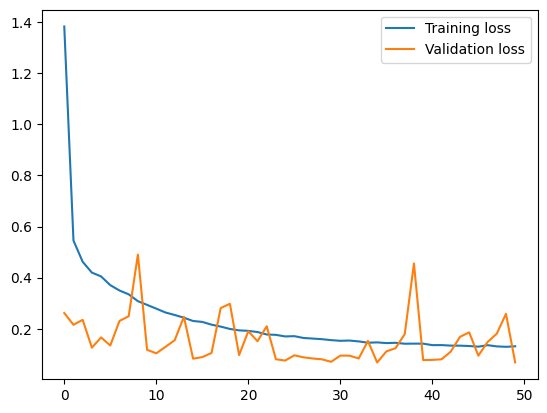

In [132]:
# ZINC 250k
plt.plot(history['loss'], label="Training loss")
plt.plot(history['val_loss'], label="Validation loss")
plt.legend()
plt.show()

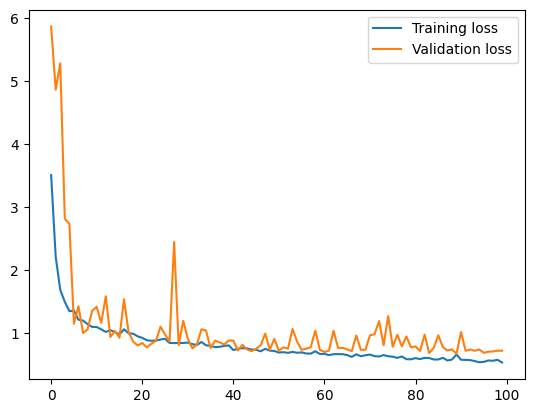

In [44]:
plt.plot(history['loss'], label="Training loss")
plt.plot(history['val_loss'], label="Validation loss")
plt.legend()
plt.show()

## Loss metrics

Epoch 100 | Train Loss: 0.5365 | Val Loss: 0.7234		Test 1.0808103449490605
Epoch 100 | Train Loss: 0.4867 | Val Loss: 0.7955		Test 1.2242626746495564
Epoch 100 | Train Loss: 0.5064 | Val Loss: 0.7212		Test 1.0636256130374209
Epoch 100 | Train Loss: 0.5586 | Val Loss: 0.7210		Test 0.974257214539716
Epoch 100 | Train Loss: 0.8262 | Val Loss: 0.7443		Test 1.0145132379466986

Epoch 050 | Train Loss: 0.1314 | Val Loss: 0.0684		Test 0.06991253985466395

In [ ]:
train_loss = [0.5365, 0.4867, 0.5064, 0.5586, 0.8262]
val_loss = [0.7234, 0.7955, 0.7212, 0.7210, 0.7443]
test_loss = [1.0808103449490605, 1.2242626746495564, 1.0636256130374209, 0.974257214539716, 1.0145132379466986]

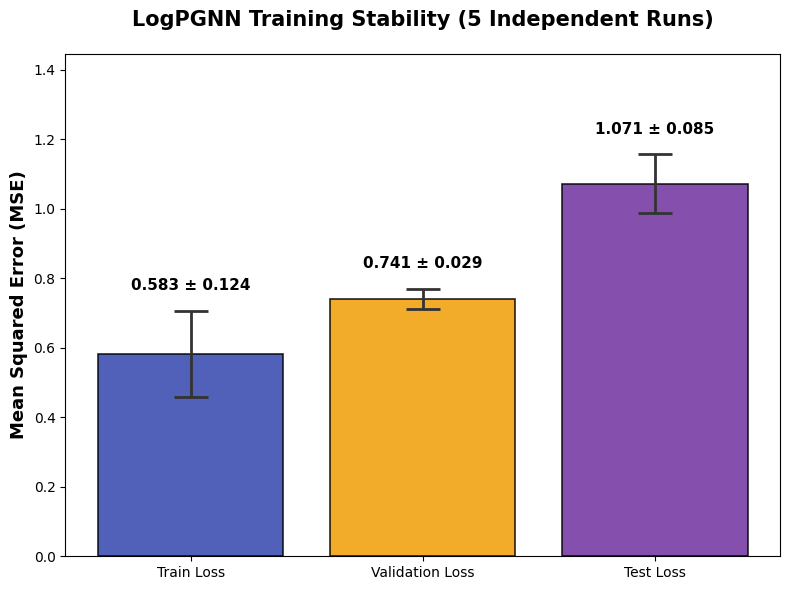

In [ ]:
loss_means = [np.mean(train_loss), np.mean(val_loss), np.mean(test_loss)]
loss_stds = [np.std(train_loss), np.std(val_loss), np.std(test_loss)]
loss_labels = ['Train Loss', 'Validation Loss', 'Test Loss']

plt.figure(figsize=(8, 6))

bars = plt.bar(
    loss_labels, 
    loss_means, 
    yerr=loss_stds, 
    capsize=12, 
    color=['#3344ad', '#f19d04', '#7030a0'], 
    edgecolor='black',
    linewidth=1.2,
    alpha=0.85,
    error_kw={'elinewidth': 2, 'capthick': 2, 'ecolor': '#333333'}
)

for bar, mean, std in zip(bars, loss_means, loss_stds):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        mean + std + 0.05,  # type: ignore
        f'{mean:.3f} ± {std:.3f}', 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        fontsize=11
    )

plt.ylabel('Mean Squared Error (MSE)', fontsize=13, fontweight='bold')
plt.title('LogPGNN Training Stability (5 Independent Runs)', fontsize=15, fontweight='bold', pad=20)

plt.ylim(0, max(loss_means) + max(loss_stds) + 0.25) 

plt.tight_layout()
plt.show()

## Save weights

In [28]:
model.save("logp_gnn_weights_sangster2.pth")

Model weights saved to logp_gnn_weights_sangster2.pth


# Test

## Load weights

In [22]:
# model.load("logp_gnn_weights_sangster1.pth")
model.load("logp_gnn_weights_zinc.pth")

Model weights loaded from logp_gnn_weights_zinc.pth


## Evaluate

In [36]:
model.evaluate(test_data, batch_size=4_096)

1.0808103449490605

## Regression Prediction

In [133]:
pred_logp = model.predict(test_data, batch_size=4_096)

### Crippen Method

Calculating Crippen baseline: 100%|██████████| 4704/4704 [00:02<00:00, 2227.89it/s]


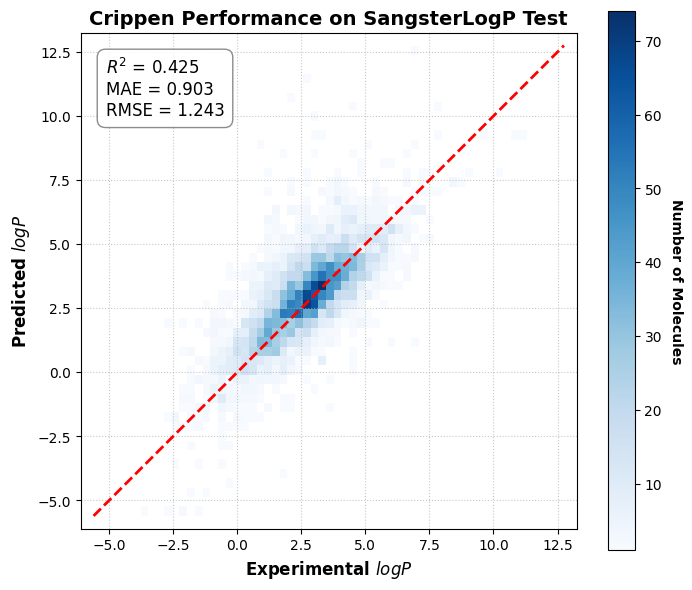

In [ ]:
pred_logp_list = []
for smiles in tqdm(test_smiles, desc="Calculating Crippen baseline"):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        logp = Descriptors.MolLogP(mol)     #type: ignore
        pred_logp_list.append(logp)
    else:
        pred_logp_list.append(np.nan)
pred_logp = np.array(pred_logp_list)

r2 = r2_score(test_logp, pred_logp)
mae = mean_absolute_error(test_logp, pred_logp)
rmse = root_mean_squared_error(test_logp, pred_logp)

plt.figure(figsize=(8, 7)) 

h = plt.hist2d(test_logp, pred_logp, bins=50, cmap='Blues', cmin=1)
cbar = plt.colorbar(h[3])
cbar.set_label('Number of Molecules', rotation=270, labelpad=15, fontweight='bold')

min_val = min(np.min(test_logp), np.min(pred_logp))
max_val = max(np.max(test_logp), np.max(pred_logp))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Perfect Prediction', zorder=5)

metrics_text = f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.axis('square')
plt.xlim([min_val - 0.5, max_val + 0.5])
plt.ylim([min_val - 0.5, max_val + 0.5])
plt.xlabel('Experimental $logP$', fontsize=12, fontweight='bold')
plt.ylabel('Predicted $logP$', fontsize=12, fontweight='bold')
plt.title('Crippen Performance on SangsterLogP Test', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7, zorder=0)

plt.show()

In [ ]:
r2 = r2_score(test_logp, pred_logp)
mae = mean_absolute_error(test_logp, pred_logp)
rmse = root_mean_squared_error(test_logp, pred_logp)

plt.figure(figsize=(8, 7)) 

h = plt.hist2d(test_logp, pred_logp, bins=50, cmap='Blues', cmin=1)
cbar = plt.colorbar(h[3])
cbar.set_label('Number of Molecules', rotation=270, labelpad=15, fontweight='bold')

min_val = min(np.min(test_logp), np.min(pred_logp))
max_val = max(np.max(test_logp), np.max(pred_logp))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Perfect Prediction', zorder=5)

metrics_text = f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.axis('square')
plt.xlim([min_val - 0.5, max_val + 0.5])
plt.ylim([min_val - 0.5, max_val + 0.5])
plt.xlabel('Experimental $logP$', fontsize=12, fontweight='bold')
plt.ylabel('Predicted $logP$', fontsize=12, fontweight='bold')
plt.title('LogPGNN Performance on Test Set', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7, zorder=0)

plt.show()

In [21]:
pred_logp = model.predict(test_data, batch_size=4_096)

In [34]:
from sklearn.metrics import mean_squared_error
mean_squared_error(test_logp, pred_logp)

1.0808104200057658

### ZINC 250k Test 

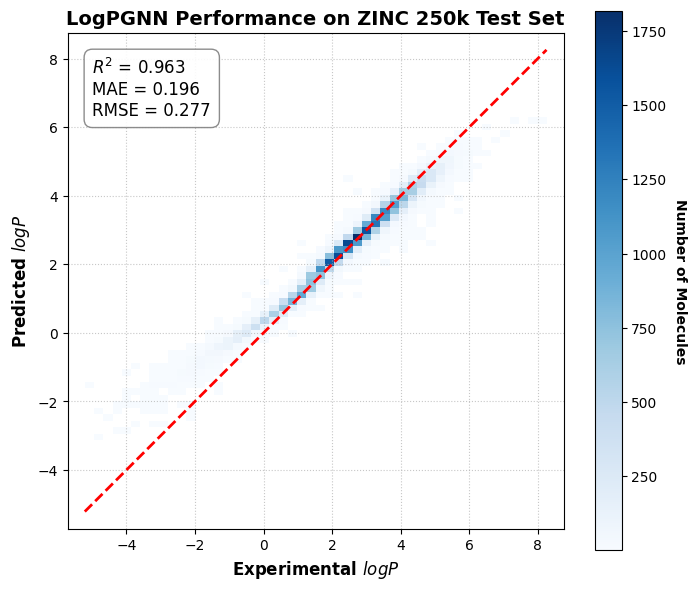

In [31]:
r2 = r2_score(test_logp, pred_logp)
mae = mean_absolute_error(test_logp, pred_logp)
rmse = root_mean_squared_error(test_logp, pred_logp)

plt.figure(figsize=(8, 7)) 

h = plt.hist2d(test_logp, pred_logp, bins=50, cmap='Blues', cmin=1)
cbar = plt.colorbar(h[3])
cbar.set_label('Number of Molecules', rotation=270, labelpad=15, fontweight='bold')

min_val = min(np.min(test_logp), np.min(pred_logp))
max_val = max(np.max(test_logp), np.max(pred_logp))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Perfect Prediction', zorder=5)

metrics_text = f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.axis('square')
plt.xlim([min_val - 0.5, max_val + 0.5])
plt.ylim([min_val - 0.5, max_val + 0.5])
plt.xlabel('Experimental $logP$', fontsize=12, fontweight='bold')
plt.ylabel('Predicted $logP$', fontsize=12, fontweight='bold')
plt.title('LogPGNN Performance on ZINC 250k Test Set', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7, zorder=0)

plt.show()

### SangsterLogP Test

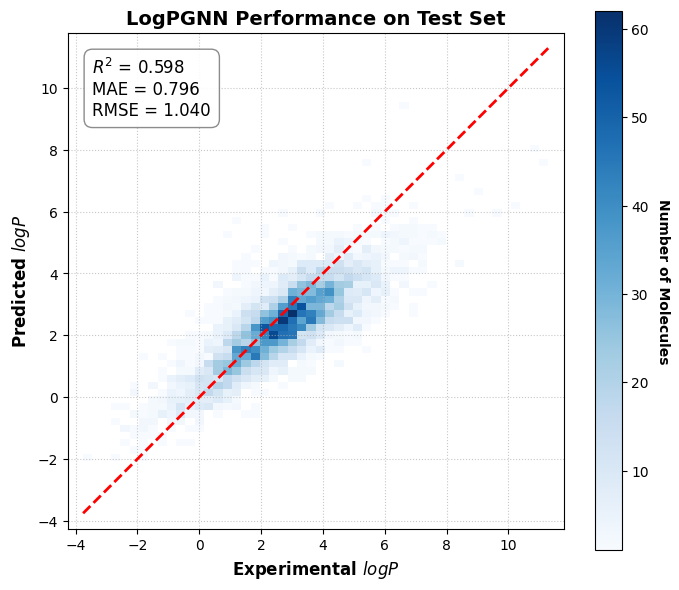

In [36]:
r2 = r2_score(test_logp, pred_logp)
mae = mean_absolute_error(test_logp, pred_logp)
rmse = root_mean_squared_error(test_logp, pred_logp)

plt.figure(figsize=(8, 7)) 

h = plt.hist2d(test_logp, pred_logp, bins=50, cmap='Blues', cmin=1)
cbar = plt.colorbar(h[3])
cbar.set_label('Number of Molecules', rotation=270, labelpad=15, fontweight='bold')

min_val = min(np.min(test_logp), np.min(pred_logp))
max_val = max(np.max(test_logp), np.max(pred_logp))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Perfect Prediction', zorder=5)

metrics_text = f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.axis('square')
plt.xlim([min_val - 0.5, max_val + 0.5])
plt.ylim([min_val - 0.5, max_val + 0.5])
plt.xlabel('Experimental $logP$', fontsize=12, fontweight='bold')
plt.ylabel('Predicted $logP$', fontsize=12, fontweight='bold')
plt.title('LogPGNN Performance on Test Set', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7, zorder=0)

plt.show()

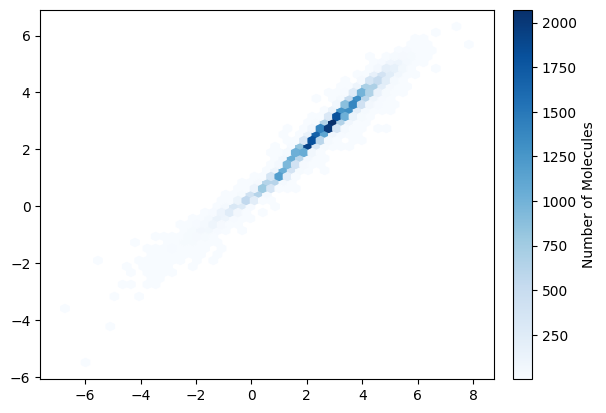

In [138]:
plt.hexbin(test_logp, pred_logp, gridsize=50, cmap='Blues', mincnt=1)
cb = plt.colorbar(fraction=0.046, pad=0.04)
cb.set_label('Number of Molecules')

## Classification

In [37]:
print(f"bR05 in dataset:    {sum(1 for x in logp_dataset if x > 5) / len(logp_dataset) * 100:.4f} %")
print(f"bR05 in training:   {sum(1 for x in train_logp if x > 5) / len(train_logp) * 100:.4f} %")
print(f"bR05 in validation: {sum(1 for x in val_logp if x > 5) / len(val_logp) * 100:.4f} %")
print(f"bR05 in testing:    {sum(1 for x in test_logp if x > 5) / len(test_logp) * 100:.4f} %")

bR05 in dataset:    6.3478 %
bR05 in training:   6.4334 %
bR05 in validation: 4.1614 %
bR05 in testing:    7.1429 %


In [38]:
# 1 for PASS, 0 for FAIL
logp_threshold = 5.0
test_class = [1 if x <= logp_threshold else 0 for x in test_logp] 
pred_class = [1 if x <= logp_threshold else 0 for x in pred_logp]

class_labels = [1,0]
display_labels = ["PASS", "FAIL"]

### Confusion Matrix

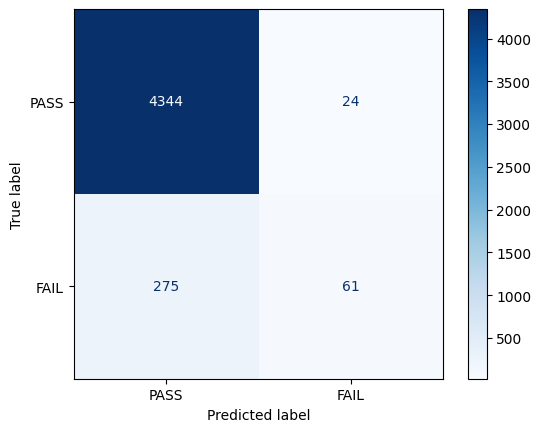

In [39]:
cm = confusion_matrix(test_class, pred_class, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.show()

### Classification Report

In [40]:
print(classification_report(test_class, pred_class, labels=class_labels, target_names=display_labels))

              precision    recall  f1-score   support

        PASS       0.94      0.99      0.97      4368
        FAIL       0.72      0.18      0.29       336

    accuracy                           0.94      4704
   macro avg       0.83      0.59      0.63      4704
weighted avg       0.92      0.94      0.92      4704



In [41]:
print(f"MCC = {matthews_corrcoef(test_class, pred_class):.4f}")

MCC = 0.3404


### PR Curve

This PR curve focuses on the minority bRo5 molecules (i.e., logP > 5).

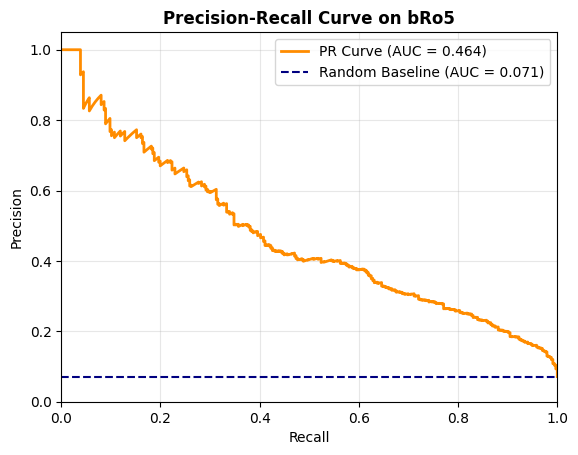

In [105]:
precision, recall, thresholds = precision_recall_curve(test_class, pred_logp, pos_label=0)

pr_auc = auc(recall, precision)
pr_baseline = 1 - sum(test_class) / len(test_class)

plt.plot(recall, precision, color='darkorange', lw=2, 
         label=f'PR Curve (AUC = {pr_auc:.3f})')

plt.axhline(y=pr_baseline, color='navy', linestyle='--', 
            label=f'Random Baseline (AUC = {pr_baseline:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve on bRo5', fontweight='bold')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.show()

### Graph

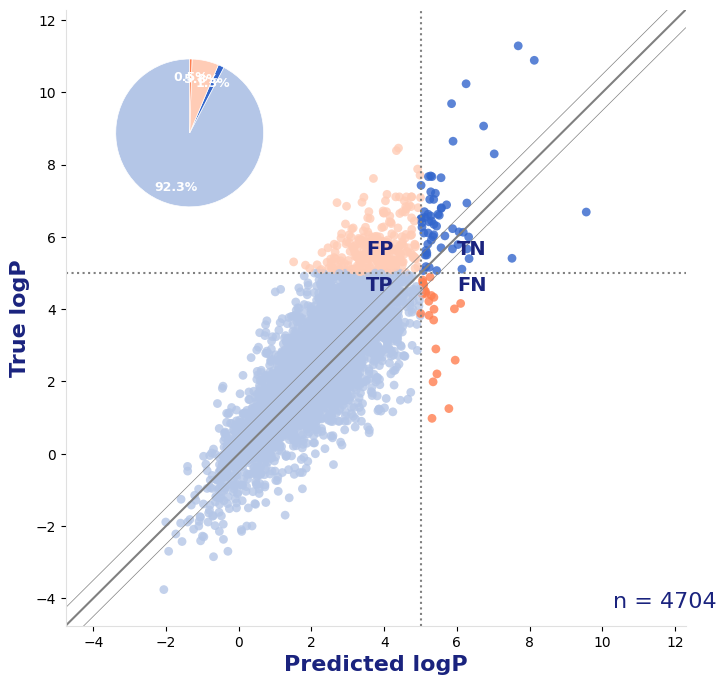

In [56]:
margin = 0.5

color_idx = []
counts = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}

c_tp = '#B4C6E7' # Faint blue
c_tn = '#3366CC' # Blue
c_fp = '#FFCCB6' # Faint orange
c_fn = '#FF7F50' # Orange

for true_val, pred_val in zip(test_class, pred_class):
    if true_val and pred_val:       # True PASS, Pred PASS
        color_idx.append(c_tp)
        counts['TP'] += 1
    elif not true_val and not pred_val: # True FAIL, Pred FAIL
        color_idx.append(c_tn)
        counts['TN'] += 1
    elif not true_val and pred_val:     # True FAIL, Pred PASS
        color_idx.append(c_fp)
        counts['FP'] += 1
    elif true_val and not pred_val:     # True PASS, Pred FAIL
        color_idx.append(c_fn)
        counts['FN'] += 1

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the scatter points
ax.scatter(pred_logp, test_logp, c=color_idx, alpha=0.8, s=40, edgecolor='none')

# 4. Add the Threshold Lines (The Quadrants)
ax.axvline(logp_threshold, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(logp_threshold, color='gray', linestyle=':', linewidth=1.5)

# 5. Add the Identity Line (y=x) and Error Margins
# Find the min/max bounds of the data to draw the diagonal lines perfectly
min_val = min(min(test_logp), min(pred_logp)) - 1
max_val = max(max(test_logp), max(pred_logp)) + 1

# Main y=x line
ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='-', linewidth=1.5)

# Upper and lower margin lines  
ax.plot([min_val, max_val], [min_val + margin, max_val + margin], color='gray', linestyle='-', linewidth=0.5)
ax.plot([min_val, max_val], [min_val - margin, max_val - margin], color='gray', linestyle='-', linewidth=0.5)

# 6. Formatting the Axes
ax.set_xlim([min_val, max_val]) # type: ignore
ax.set_ylim([min_val, max_val]) # type: ignore
ax.set_xlabel('Predicted logP', fontsize=16, fontweight='bold', color='#1A237E')
ax.set_ylabel('True logP', fontsize=16, fontweight='bold', color='#1A237E')

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#E0E0E0')
ax.spines['left'].set_color('#E0E0E0')

# Add text labels for the quadrants (Positioned relative to the threshold)
ax.text(logp_threshold - 1.5, logp_threshold - 0.5, 'TP', fontsize=14, fontweight='bold', color='#1A237E')
ax.text(logp_threshold + 1.0, logp_threshold + 0.5, 'TN', fontsize=14, fontweight='bold', color='#1A237E')
ax.text(logp_threshold - 1.5, logp_threshold + 0.5, 'FP', fontsize=14, fontweight='bold', color='#1A237E')
ax.text(logp_threshold + 1.0, logp_threshold - 0.5, 'FN', fontsize=14, fontweight='bold', color='#1A237E')

# Add total N count in bottom right
ax.text(max_val - 2, min_val + 0.5, f'n = {len(test_logp)}', fontsize=16, color='#1A237E')

# --- 7. THE INSET PIE CHART ---
# Create a small axes inset in the top left corner
ax_pie = ax.inset_axes([0.05, 0.65, 0.3, 0.3]) # type: ignore

pie_labels = ['TP', 'TN', 'FP', 'FN']
pie_sizes = [counts['TP'], counts['TN'], counts['FP'], counts['FN']]
pie_colors = [c_tp, c_tn, c_fp, c_fn]

# Filter out any 0-value slices to avoid pie chart errors
filtered_data = [(s, c, l) for s, c, l in zip(pie_sizes, pie_colors, pie_labels) if s > 0]
sizes, colors, labels = zip(*filtered_data) if filtered_data else ([], [], [])

if sizes:
    wedges, texts, autotexts = ax_pie.pie( # type: ignore
        sizes, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=90,
        pctdistance=0.75,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'}
    )
    # Style the pie chart text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')

plt.show()

# Explainability

## Baseline

### Global Baseline

In [23]:
def get_dataset_baselines(
    train: list[Data], device
) -> tuple:
    """Calculates the mean node and edge feature vectors across the entire training set."""
    train_loader = DataLoader(train, batch_size=2_048, shuffle=False, num_workers=0)
    
    total_node_features = 0
    total_atoms = 0
    
    total_edge_features = 0
    total_bonds = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        
        # Nodes
        total_node_features += batch.x.sum(dim=0)
        total_atoms += batch.x.shape[0]
        
        # Edges
        if batch.edge_attr is not None and batch.edge_attr.shape[0] > 0:
            total_edge_features += batch.edge_attr.sum(dim=0)
            total_bonds += batch.edge_attr.shape[0]
            
    mean_node_vector = total_node_features / total_atoms
    
    if total_bonds > 0:
        mean_edge_vector = total_edge_features / total_bonds
    else:   # if no bonds in the entire input
        dummy_edge_dim = train[0].edge_attr.shape[1] if train[0].edge_attr is not None else 1
        mean_edge_vector = torch.zeros(dummy_edge_dim, device=device)
        
    return mean_node_vector, mean_edge_vector

global_baseline_node, global_baseline_edge = get_dataset_baselines(train_data, device)

print("Global Baseline Node Feature Vector:", global_baseline_node)
print("Global Baseline Edge Feature Vector:", global_baseline_edge)

Global Baseline Node Feature Vector: tensor([4.0127, 2.0704, 0.0000, 2.3620, 0.0045, 0.0045, 1.7653, 0.2255, 0.3152,
        0.0321], device='cuda:4')
Global Baseline Edge Feature Vector: tensor([1.1492, 0.0041, 0.3148], device='cuda:4')


### Baseline Prediction

In [24]:
def predict_baseline_logp(
    model, data, global_baseline_node, global_baseline_edge
) -> float:
    model.eval()
    device = next(model.parameters()).device
    data = data.to(device)
    
    with torch.no_grad():
        num_atoms = data.x.shape[0]
        num_edges = data.edge_attr.shape[0] if data.edge_attr is not None else 0
        
        # Ghost Graph
        ghost_x = global_baseline_node.repeat(num_atoms, 1).to(device)
        if num_edges > 0:
            ghost_edge_attr = global_baseline_edge.repeat(num_edges, 1).to(device)
        else:
            ghost_edge_attr = torch.empty((0, global_baseline_edge.shape[0]), device=device)

        baseline_pred = model(
            x=ghost_x, 
            edge_index=data.edge_index, 
            edge_attr=ghost_edge_attr, 
            batch=data.batch
        )
        
    return baseline_pred.item()

# Random molecule
test_molecule = train_data[42]
baseline_val = predict_baseline_logp(model, test_molecule, global_baseline_node, global_baseline_edge)
print(f"Baseline logP Offset: {baseline_val:.4f}")

Baseline logP Offset: -0.2719


### Model Forward

In [25]:
def get_model_forward(
    model, data, global_baseline_node, global_baseline_edge
) -> tuple:
    model.eval()
    device = next(model.parameters()).device
    data = data.to(device)
    
    input_node = data.x.unsqueeze(0).requires_grad_()
    num_atoms = data.x.shape[0]
    baseline_node = global_baseline_node.repeat(num_atoms, 1).unsqueeze(0).to(device)
    
    input_edge = data.edge_attr.unsqueeze(0).requires_grad_()
    num_bonds = data.edge_attr.shape[0]
    baseline_edge = global_baseline_edge.repeat(num_bonds, 1).unsqueeze(0).to(device)

    def model_forward(node_input, edge_input):
        # [captum_steps, num_atoms, num_features]
        captum_steps = node_input.shape[0]
        
        # [captum_steps * num_atoms, num_features]
        x_pyg = node_input.view(-1, node_input.shape[-1])
        
        edge_attr_pyg = edge_input.view(-1, edge_input.shape[-1])

        edge_indices = []
        for i in range(captum_steps):
            offset = i * num_atoms
            edge_indices.append(data.edge_index + offset)
        edge_index_pyg = torch.cat(edge_indices, dim=1)
        
        batch_pyg = torch.arange(captum_steps, device=device).repeat_interleave(num_atoms)
        
        return model(x_pyg, edge_index_pyg, edge_attr_pyg, batch_pyg)
    
    return model_forward, (input_node, input_edge), (baseline_node, baseline_edge)

## Crippen Method

In [26]:
def crippen_logp(smiles: str) -> None:
    mol = Chem.MolFromSmiles(smiles)
    mol_h = Chem.AddHs(mol)
    ator_contribs = Chem.rdMolDescriptors._CalcCrippenContribs(mol_h) # type: ignore
    summed_logp = sum([atom_data[0] for atom_data in ator_contribs])

    num_heavy_atoms = mol.GetNumAtoms()
    logp_weights = [0.0] * num_heavy_atoms    
    for i, atom in enumerate(mol_h.GetAtoms()):
        logp_val = ator_contribs[i][0]
        if atom.GetAtomicNum() == 1:
            neighbor = atom.GetNeighbors()[0]
            heavy_idx = neighbor.GetIdx()
            logp_weights[heavy_idx] += logp_val
        else:
            logp_weights[i] += logp_val
            
    print(f"Crippen predicted logP: {summed_logp:.4f}")

    d = Chem.Draw.MolDraw2DCairo(600, 400)  # type: ignore
    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        logp_weights,
        draw2d=d,
        colorMap='PiYG',
        contourLines=10
    )
    d.FinishDrawing()
    display(Image(d.GetDrawingText()))

## Integrated Gradients

In [27]:
def explain_logp_ig(
    model,
    data: Data,
    global_baseline_node: torch.Tensor,
    global_baseline_edge: torch.Tensor,
    show_error: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    model_forward, inputs, baselines = get_model_forward(
        model, data, global_baseline_node, global_baseline_edge
    )

    ig = IntegratedGradients(model_forward)
    attributions, delta = ig.attribute(
        inputs=inputs,
        baselines=baselines,
        n_steps=500,
        return_convergence_delta=True
    )
    
    delta_val = delta.item()
    if show_error and abs(delta_val) > 0.05:
        print(f"WARNING: High IG approximation error (Delta = {delta_val:.4f}).")
        print("Heatmap may be inaccurate! Try increasing n_steps in ig.attribute().")
    
    # [1, Num_Atoms/Nume_Bonds, Features]
    atom_importance_scores = attributions[0].squeeze(0).sum(dim=1)
    bond_importance_scores = attributions[1].squeeze(0).sum(dim=1)
    
    return atom_importance_scores.detach().cpu().numpy(), bond_importance_scores.detach().cpu().numpy()

## Attention

In [28]:
def visualize_bond_attention(model, smiles: str) -> None:
    mol = MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES.")
        return
    
    model.eval()
    data = DataFromSmiles(smiles)
    device = next(model.parameters()).device
    data = data.to(device)
    if getattr(data, 'batch', None) is None:
        batch_vector = torch.zeros(data.x.shape[0], dtype=torch.long, device=device)     # type: ignore
    else:
        batch_vector = data.batch.to(device)    # type: ignore
    with torch.no_grad():
        prediction, (edge_idx, attn_weights) = model(
            data.x, 
            data.edge_index,
            data.edge_attr,
            batch_vector, 
            return_attention=True
        )
    mean_attention = attn_weights.mean(dim=1).squeeze().tolist()
    
    bond_attention_dict: dict[tuple[int, int], list[float]] = {}
    for k in range(edge_idx.shape[1]):
        i = edge_idx[0, k].item()
        j = edge_idx[1, k].item()
        
        if i == j:
            continue

        bond_key = (min(i, j), max(i, j))
        
        if bond_key not in bond_attention_dict:
            bond_attention_dict[bond_key] = []
        bond_attention_dict[bond_key].append(mean_attention[k])

    bond_attention_dict_ave: dict[tuple[int, int], float] = {}
    for b_key in bond_attention_dict:
        scores = bond_attention_dict[b_key]
        bond_attention_dict_ave[b_key] = sum(scores) / len(scores)
    
    if not bond_attention_dict_ave:
        print("No bonds to visualize!")
        return
            
    max_w = max(bond_attention_dict_ave.values())
    min_w = min(bond_attention_dict_ave.values())
    
    cmap = plt.get_cmap('Greens')
    highlight_bonds: list[int] = []
    highlight_bond_colors: dict[int, tuple[float, float, float, float]] = {}
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        b_key = (min(i, j), max(i, j))
        
        if b_key in bond_attention_dict_ave:
            w = bond_attention_dict_ave[b_key]
            norm_w = (w - min_w) / (max_w - min_w + 1e-8)
            
            # rgba = cmap(0.2 + 0.8 * norm_w)
            rgba = cmap(norm_w) 
            
            bond_idx = bond.GetIdx()
            highlight_bonds.append(bond_idx)
            highlight_bond_colors[bond_idx] = rgba

    drawer = rdMolDraw2D.MolDraw2DCairo(600, 400)
    options = drawer.drawOptions()
    options.bondLineWidth = 4 
    options.clearBackground = False
    
    drawer.DrawMolecule(
        mol,
        highlightAtoms=[],
        highlightBonds=highlight_bonds,
        highlightBondColors=highlight_bond_colors
    )
    drawer.FinishDrawing()
    
    display(Image(drawer.GetDrawingText()))

## SHAP

In [29]:
def explain_logp_shap(
    model,
    data,
    global_baseline_node,
    global_baseline_edge,
    ignore_edges: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    model_forward, inputs, baselines = get_model_forward(
        model, data, global_baseline_node, global_baseline_edge
    )

    device = inputs[0].device
    num_atoms, num_node_features = data.x.shape
    num_directed_edges, num_edge_features = data.edge_attr.shape
    
    node_mask = torch.arange(num_atoms, device=device).unsqueeze(1).repeat(1, num_node_features).unsqueeze(0)
    
    # Ignoring edges
    if ignore_edges:
        def frozen_edge_forward(x_perturbed):
            batch_size = x_perturbed.shape[0]
            edge_frozen = inputs[1].repeat(batch_size, 1, 1)
            return model_forward(x_perturbed, edge_frozen)
        
        shap_explainer = ShapleyValueSampling(frozen_edge_forward)
        
        attributions = shap_explainer.attribute(
            inputs=inputs[0],
            baselines=baselines[0],
            target=0,
            feature_mask=node_mask,
            n_samples=100,      
            show_progress=True
        )
        
        atom_importance_scores = attributions[0].squeeze(0).mean(dim=1).detach().cpu().numpy()        
        bond_importance_scores = np.zeros(num_directed_edges, dtype=np.float32)
    
    # Include edges
    else:
        edge_player_ids = torch.full((num_directed_edges,), -1, dtype=torch.long, device=device)
        assigned_bonds = {}
        current_bond_id = num_atoms
        for i in range(num_directed_edges):
            src = data.edge_index[0, i].item()
            dst = data.edge_index[1, i].item()
            bond_key = tuple(sorted((src, dst)))
            if bond_key not in assigned_bonds:
                assigned_bonds[bond_key] = current_bond_id
                current_bond_id += 1
            edge_player_ids[i] = assigned_bonds[bond_key]
        edge_mask = edge_player_ids.unsqueeze(1).repeat(1, num_edge_features).unsqueeze(0)

        shap_explainer = ShapleyValueSampling(model_forward)

        attributions = shap_explainer.attribute(
            inputs=inputs,
            baselines=baselines,
            target=0,
            feature_mask=(node_mask, edge_mask),
            n_samples=100,      
            show_progress=True
        )
        
        atom_importance_scores = attributions[0].squeeze(0).mean(dim=1).detach().cpu().numpy()
        bond_importance_scores = (attributions[1].squeeze(0).mean(dim=1) / 2.0).detach().cpu().numpy()
        
    return atom_importance_scores, bond_importance_scores

## Drawing

In [30]:
def logp_heatmap(
    model, smiles: str, logp: float | None = None, method: str = 'ig'
) -> None:
    graph_data = DataFromSmiles(smiles, logp)
    
    if logp is None:
        logp = model.predict([graph_data])[0]
        print(f"Predicted logP: {logp:.4f}")
    else:
        print(f"Experimental logP: {logp:.4f}")

    if method == 'ig':
        atom_scores, bond_scores = explain_logp_ig(model, graph_data, global_baseline_node, global_baseline_edge)
    elif method == 'shap':
        atom_scores, bond_scores = explain_logp_shap(model, graph_data, global_baseline_node, global_baseline_edge)
    else:
        raise ValueError(f"No method {method} exists.")
    
    print(f"atom attr = {sum(atom_scores):.4f}")
    print(f"bond attr = {sum(bond_scores):.4f}")
    print(f"total attr = {sum(atom_scores) + sum(bond_scores) + baseline_val:.4f}")

    # aggregate bond scores to atoms
    for edge_idx in range(graph_data.edge_index.shape[1]):  # type: ignore
        src = graph_data.edge_index[0, edge_idx].item()     # type: ignore
        dst = graph_data.edge_index[1, edge_idx].item()     # type: ignore
        
        atom_scores[src] += bond_scores[edge_idx] / 2.0     # type: ignore
        atom_scores[dst] += bond_scores[edge_idx] / 2.0     # type: ignore

    mol_Hs = Chem.MolFromSmiles(smiles)
    mol_Hs = Chem.AddHs(mol_Hs)
    if len(atom_scores) != mol_Hs.GetNumAtoms():
        raise ValueError("Atom count mismatch between GNN and RDKit!")
    
    mol = Chem.MolFromSmiles(smiles)
    AllChem.Compute2DCoords(mol)  # type: ignore
    collapsed_scores = [0.0] * mol.GetNumAtoms()
    
    for i, atom in enumerate(mol_Hs.GetAtoms()):
        if atom.GetAtomicNum() == 1:  # aggregate H info to heavy atom
            neighbor_idx = atom.GetNeighbors()[0].GetIdx()
            collapsed_scores[neighbor_idx] += atom_scores[i]
        else:  
            collapsed_scores[i] += atom_scores[i]

    weights = [float(w) for w in collapsed_scores]
    
    drawer = rdMolDraw2D.MolDraw2DCairo(600, 400)
    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        weights,
        draw2d=drawer,
        colorMap='PiYG',
        contourLines=10,
        alpha=0.5
    )
    drawer.FinishDrawing()
    
    display(Image(drawer.GetDrawingText()))

## Completeness

Predicted logP: 1.1674


Shapley Value Sampling attribution: 100%|██████████| 801/801 [00:04<00:00, 166.78it/s]

atom attr = 1.1069
bond attr = 0.0000
total attr = 1.1674


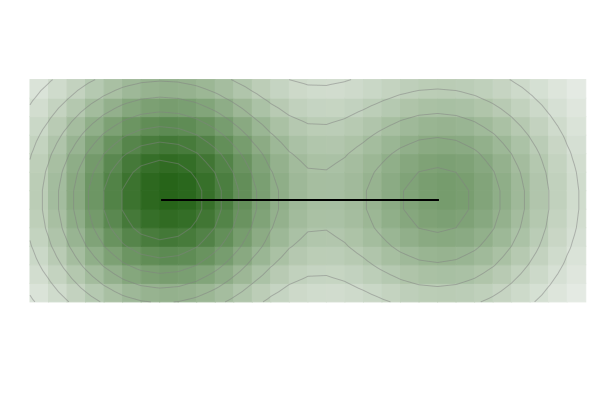

In [74]:
chem_test = "CC"

# crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='shap')

Predicted logP: 3.0917


Shapley Value Sampling attribution: 100%|██████████| 7601/7601 [00:42<00:00, 178.90it/s]

atom attr = 3.0312
bond attr = 0.0000
total attr = 3.0917


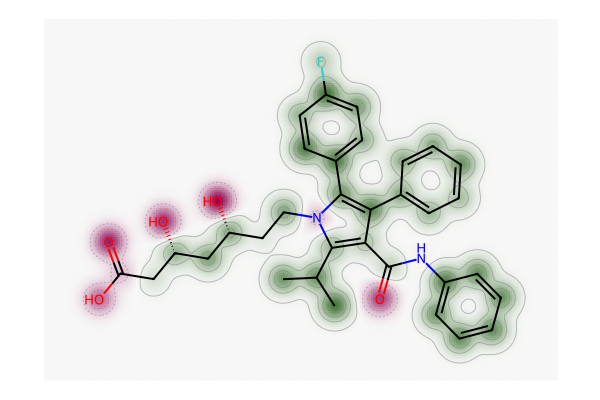

In [76]:
chem_test = "O=C(O)C[C@H](O)C[C@H](O)CCn2c(c(c(c2c1ccc(F)cc1)c3ccccc3)C(=O)Nc4ccccc4)C(C)C"

# crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='shap')

## Examples

### Random Test

Index: 1727
Actual logP: 4.33
Crippen predicted logP: 6.4446


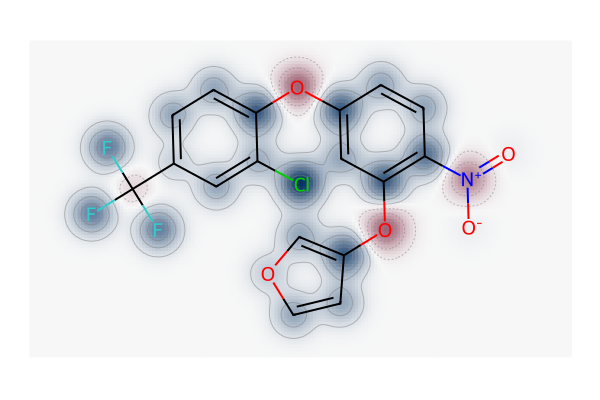

Predicted logP: 3.6032
atom attr = 3.3955
bond attr = 0.1505
total attr = 3.6065


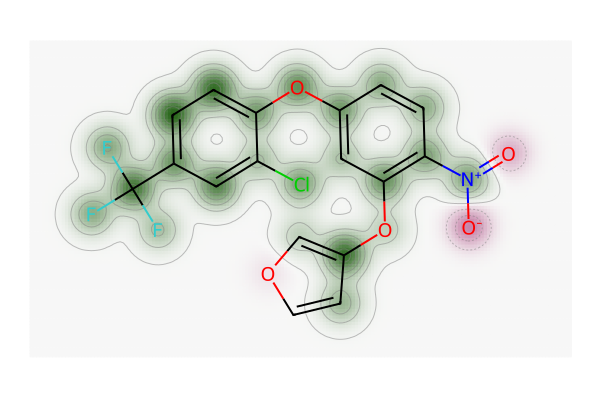

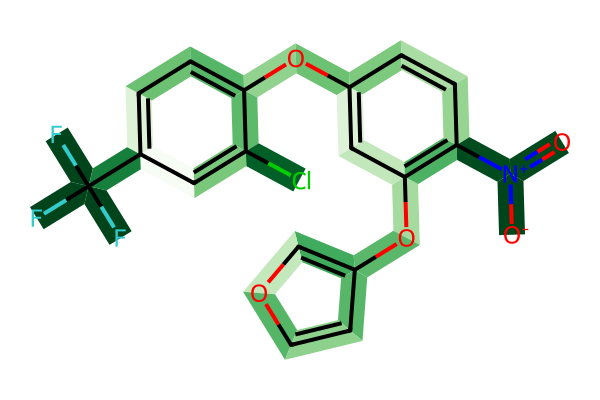

Predicted logP: 3.6032


Shapley Value Sampling attribution: 100%|██████████| 11201/11201 [01:04<00:00, 174.30it/s]

atom attr = 3.4132
bond attr = 0.1296
total attr = 3.6032


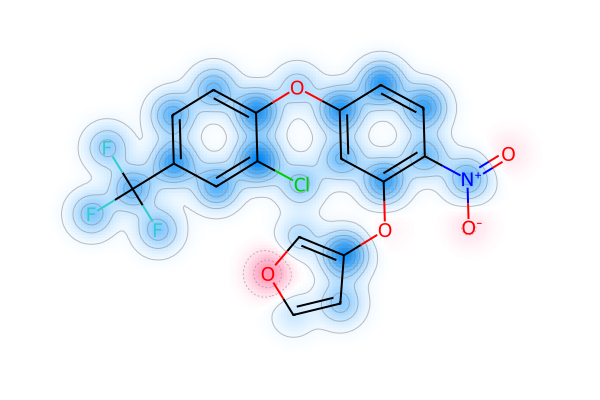

In [49]:
test = random.randint(0, len(test_logp)-1)
# test = 1811     # SangsterLogP 1
test = 1727     # SangsterLogP 2
# test = 24180 # ZINC 250k

chem_test = test_smiles[test]

print(f"Index: {test}")
print(f"Actual logP: {test_logp[test]}")

crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='ig')
visualize_bond_attention(model, chem_test)
logp_heatmap(model, chem_test, method='shap')

### Benzene

Actual logP: 2.13
Crippen predicted logP: 1.6866


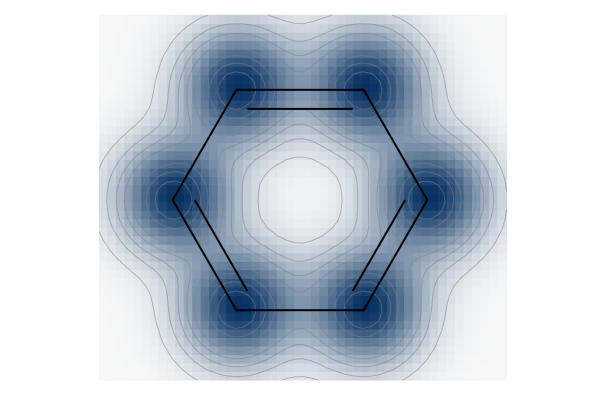

Predicted logP: 1.6822
atom attr = 1.5901
bond attr = 0.0221
total attr = 1.6727


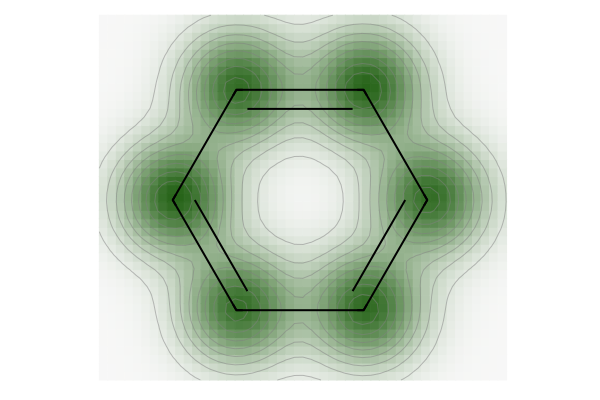

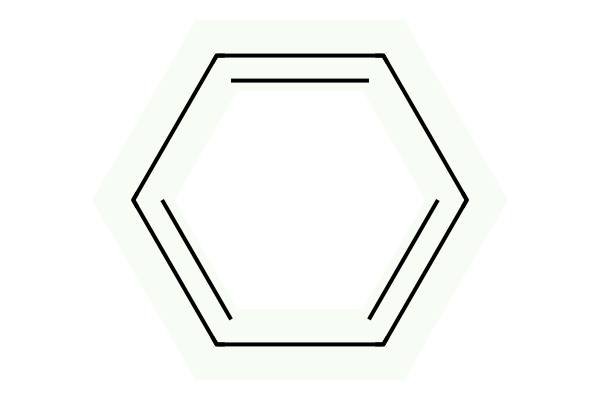

Predicted logP: 1.6822


Shapley Value Sampling attribution: 100%|██████████| 3601/3601 [00:20<00:00, 179.09it/s]

atom attr = 1.4793
bond attr = 0.1425
total attr = 1.6822


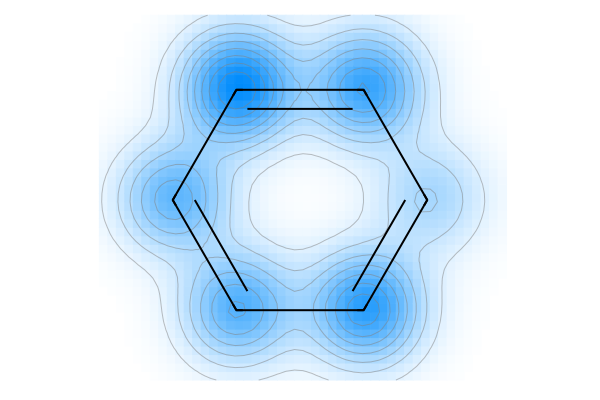

In [35]:
chem_test = "c1ccccc1"

print("Actual logP: 2.13")

crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='ig')
visualize_bond_attention(model, chem_test)
logp_heatmap(model, chem_test, method='shap')

### Phenol

Actual logP: 1.48
Crippen predicted logP: 1.3922


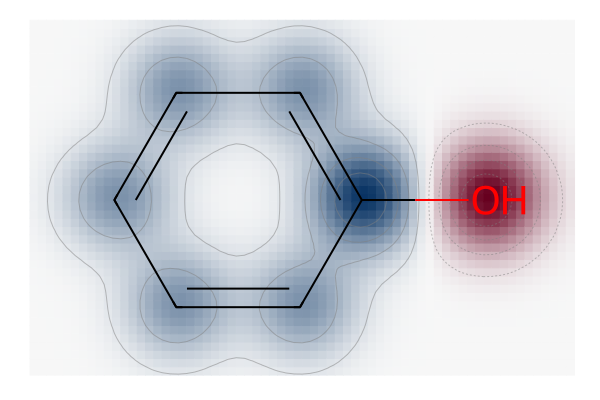

Predicted logP: 1.2692
atom attr = 1.2112
bond attr = -0.0011
total attr = 1.2706


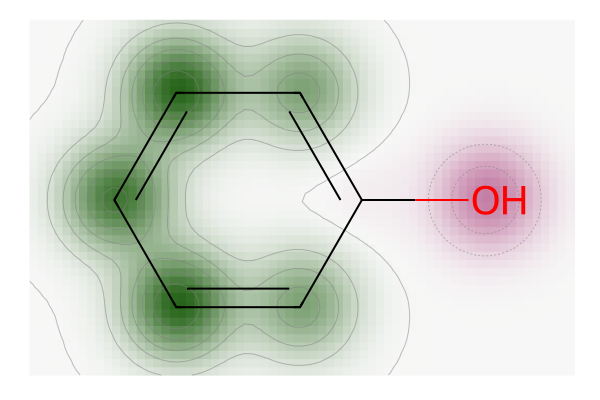

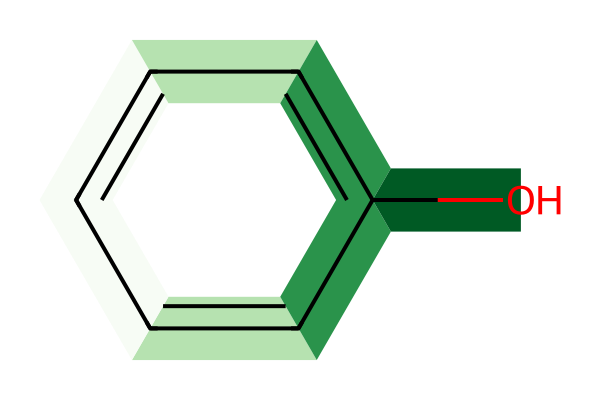

Predicted logP: 1.2692


Shapley Value Sampling attribution: 100%|██████████| 3901/3901 [00:21<00:00, 178.71it/s]

atom attr = 1.0898
bond attr = 0.1189
total attr = 1.2692


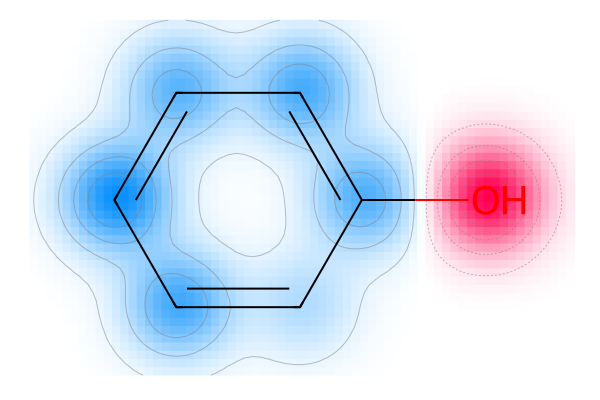

In [45]:
chem_test = "c1ccccc1O"

print("Actual logP: 1.48")

crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='ig')
visualize_bond_attention(model, chem_test)
logp_heatmap(model, chem_test, method='shap')

### Sampl6 SM12

Actual logP: 3.83
Crippen predicted logP: 4.0268


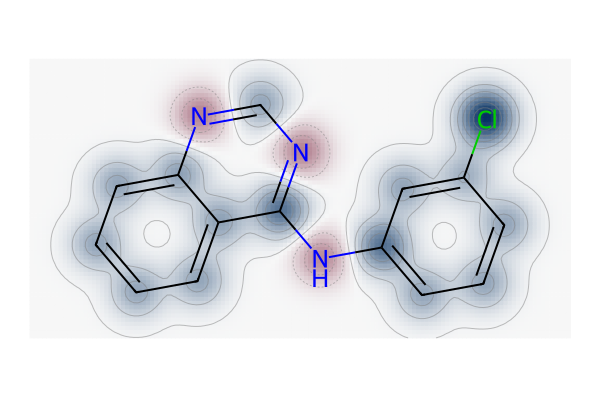

Predicted logP: 3.3256
atom attr = 3.1822
bond attr = 0.0763
total attr = 3.3189


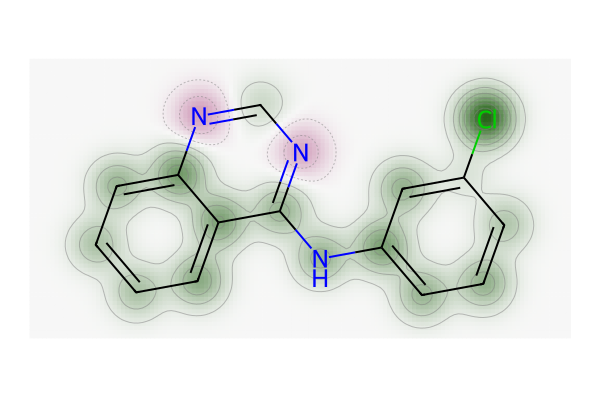

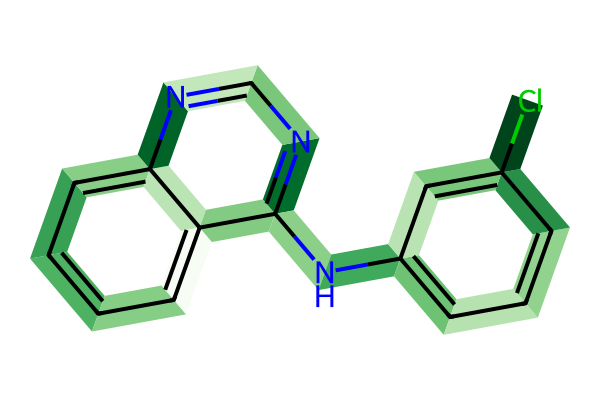

Predicted logP: 3.3256


Shapley Value Sampling attribution: 100%|██████████| 8801/8801 [00:49<00:00, 176.41it/s]

atom attr = 3.1750
bond attr = 0.0901
total attr = 3.3256


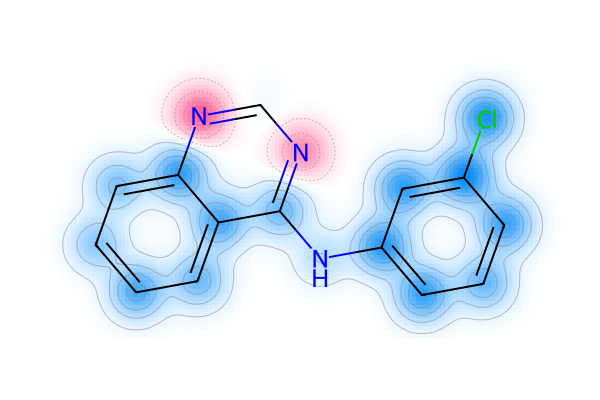

In [47]:
chem_test = "c1ccc2c(c1)c(ncn2)Nc3cccc(c3)Cl" # Sampl6 SM12

print("Actual logP: 3.83")

crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='ig')
visualize_bond_attention(model, chem_test)
logp_heatmap(model, chem_test, method='shap')

### Sampl6 SM12 w/ Counterion

Actual logP: 3.83
Crippen predicted logP: 4.4486


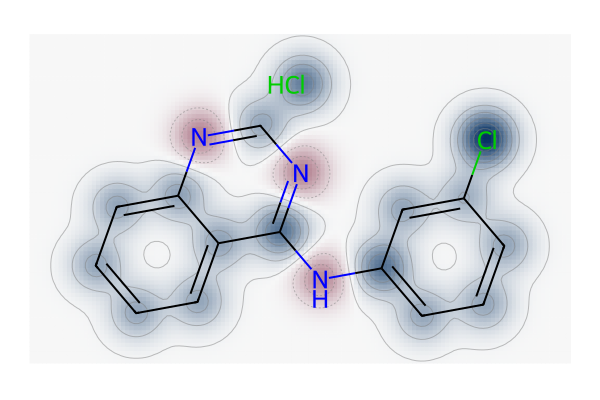

Predicted logP: 2.6182


atom attr = 2.4893
bond attr = 0.0691
total attr = 2.6189


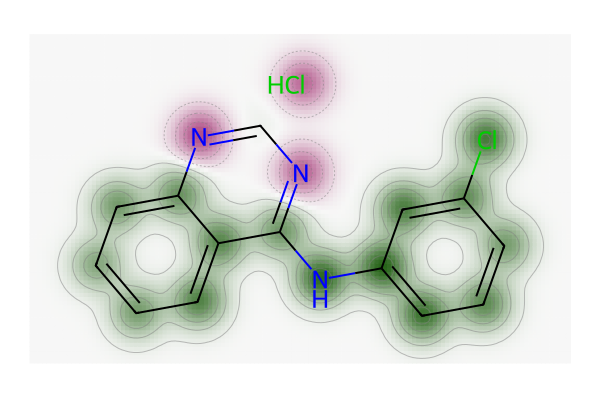

In [48]:
chem_test = "c1ccc2c(c1)c(ncn2)Nc3cccc(c3)Cl.Cl" # Sampl6 SM12

print("Actual logP: 3.83")

crippen_logp(chem_test)
logp_heatmap(model, chem_test, method='ig')
# visualize_bond_attention(model, chem_test)
# logp_heatmap(model, chem_test, method='shap')

## Heatmap Overlap

### SangsterLogP

In [123]:
crippen_arr = []
ig_arr = []

for smiles, data in tqdm(zip(test_smiles, test_data), desc="Calculating Crippen vs IG similarity", total=len(test_smiles)):
    mol = Chem.MolFromSmiles(smiles)
    mol_h = Chem.AddHs(mol)
    crippen = np.array([atom_data[0] for atom_data in Chem.rdMolDescriptors._CalcCrippenContribs(mol_h)]) # type: ignore
    
    ig = explain_logp_ig(
        model, data, global_baseline_node, global_baseline_edge, show_error=False
    )[0]
    
    crippen_arr.append(crippen)
    ig_arr.append(ig)

Calculating Crippen vs IG similarity: 100%|██████████| 4704/4704 [15:11<00:00,  5.16it/s]


In [124]:
collapsed_crippen_arr = []
collapsed_ig_arr = []

for i, smiles in tqdm(enumerate(test_smiles), total=len(test_smiles)):
    mol_Hs = Chem.AddHs(Chem.MolFromSmiles(smiles))
    num_total_atoms = mol_Hs.GetNumAtoms()
    
    collapsed_crippen = [0.0] * num_total_atoms
    collapsed_ig = [0.0] * num_total_atoms
    
    for j, atom in enumerate(mol_Hs.GetAtoms()):
        if atom.GetAtomicNum() == 1:
            neighbor_idx = atom.GetNeighbors()[0].GetIdx()
            collapsed_crippen[neighbor_idx] += crippen_arr[i][j]
            collapsed_ig[neighbor_idx] += ig_arr[i][j]
        else:
            collapsed_crippen[j] += crippen_arr[i][j]
            collapsed_ig[j] += ig_arr[i][j]
            
    heavy_atom_indices = [atom.GetIdx() for atom in mol_Hs.GetAtoms() if atom.GetAtomicNum() != 1]
    final_crippen = np.array([collapsed_crippen[idx] for idx in heavy_atom_indices])
    final_ig = np.array([collapsed_ig[idx] for idx in heavy_atom_indices])
    
    collapsed_crippen_arr.append(final_crippen)
    collapsed_ig_arr.append(final_ig)

100%|██████████| 4704/4704 [00:02<00:00, 1763.38it/s]


In [128]:
np.savez('collapsed_sangster_ig.npz', *collapsed_ig_arr)
np.savez('collapsed_sangster_crippen.npz', *collapsed_crippen_arr)

# np_load = np.load('collapsed_sangster_ig.npz')
# collapsed_ig_arr = [np_load[f'arr_{i}'] for i in range(len(np_load.files))]

# np_load = np.load('collapsed_sangster_crippen.npz')
# collapsed_crippen_arr = [np_load[f'arr_{i}'] for i in range(len(np_load.files))]

In [125]:
similarity_arr = []

for crippen, ig in tqdm(zip(collapsed_crippen_arr, collapsed_ig_arr), desc="Calculating Crippen vs IG similarity", total=len(collapsed_crippen_arr)):
    similarity = np.dot(crippen, ig) / (np.linalg.norm(crippen) * np.linalg.norm(ig))
    
    similarity_arr.append(similarity)

Calculating Crippen vs IG similarity: 100%|██████████| 4704/4704 [00:00<00:00, 131261.23it/s]


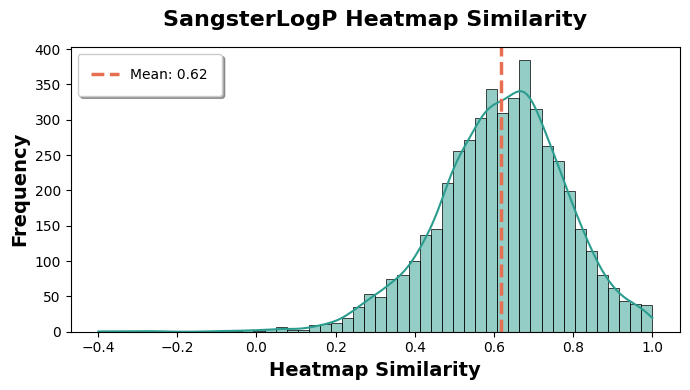

In [127]:
plt.figure(figsize=(7, 4))
ax = sns.histplot(
    data=similarity_arr,
    bins=50, 
    kde=True, 
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.5
)

mean_val = np.mean(similarity_arr)

plt.axvline(mean_val, color='#E76F51', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_val:.2f}')

plt.title('SangsterLogP Heatmap Similarity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Heatmap Similarity', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()

### ZINC 250k

In [43]:
crippen_arr = []
ig_arr = []

for smiles, data in tqdm(zip(test_smiles, test_data), desc="Calculating Crippen vs IG similarity", total=len(test_smiles)):
    mol = Chem.MolFromSmiles(smiles)
    mol_h = Chem.AddHs(mol)
    crippen = np.array([atom_data[0] for atom_data in Chem.rdMolDescriptors._CalcCrippenContribs(mol_h)]) # type: ignore
    
    ig = explain_logp_ig(
        model, data, global_baseline_node, global_baseline_edge, show_error=False
    )[0]
    
    crippen_arr.append(crippen)
    ig_arr.append(ig)

Calculating Crippen vs IG similarity: 100%|██████████| 49890/49890 [6:31:36<00:00,  2.12it/s]   


In [31]:
# np.savez('zinc_ig.npz', *ig_arr)
# np.savez('zinc_crippen.npz', *crippen_arr)

# np.savez('collapsed_zinc_ig.npz', *collapsed_ig_arr)
# np.savez('collapsed_zinc_crippen.npz', *collapsed_crippen_arr)

np_load = np.load('collapsed_zinc_ig.npz')
collapsed_ig_arr = [np_load[f'arr_{i}'] for i in range(len(np_load.files))]

np_load = np.load('collapsed_zinc_crippen.npz')
collapsed_crippen_arr = [np_load[f'arr_{i}'] for i in range(len(np_load.files))]

In [55]:
collapsed_crippen_arr = []
collapsed_ig_arr = []

for i, smiles in tqdm(enumerate(test_smiles), total=len(test_smiles)):
    mol_Hs = Chem.AddHs(Chem.MolFromSmiles(smiles))
    num_total_atoms = mol_Hs.GetNumAtoms()
    
    collapsed_crippen = [0.0] * num_total_atoms
    collapsed_ig = [0.0] * num_total_atoms
    
    for j, atom in enumerate(mol_Hs.GetAtoms()):
        if atom.GetAtomicNum() == 1:
            neighbor_idx = atom.GetNeighbors()[0].GetIdx()
            collapsed_crippen[neighbor_idx] += crippen_arr[i][j]
            collapsed_ig[neighbor_idx] += ig_arr[i][j]
        else:
            collapsed_crippen[j] += crippen_arr[i][j]
            collapsed_ig[j] += ig_arr[i][j]
            
    heavy_atom_indices = [atom.GetIdx() for atom in mol_Hs.GetAtoms() if atom.GetAtomicNum() != 1]
    final_crippen = np.array([collapsed_crippen[idx] for idx in heavy_atom_indices])
    final_ig = np.array([collapsed_ig[idx] for idx in heavy_atom_indices])
    
    collapsed_crippen_arr.append(final_crippen)
    collapsed_ig_arr.append(final_ig)

100%|██████████| 49890/49890 [00:32<00:00, 1519.38it/s]


In [24]:
similarity_arr = []

for crippen, ig in tqdm(zip(collapsed_crippen_arr, collapsed_ig_arr), desc="Calculating Crippen vs IG similarity", total=len(collapsed_crippen_arr)):
    similarity = np.dot(crippen, ig) / (np.linalg.norm(crippen) * np.linalg.norm(ig))
    
    similarity_arr.append(similarity)

Calculating Crippen vs IG similarity: 100%|██████████| 49890/49890 [00:00<00:00, 128252.03it/s]


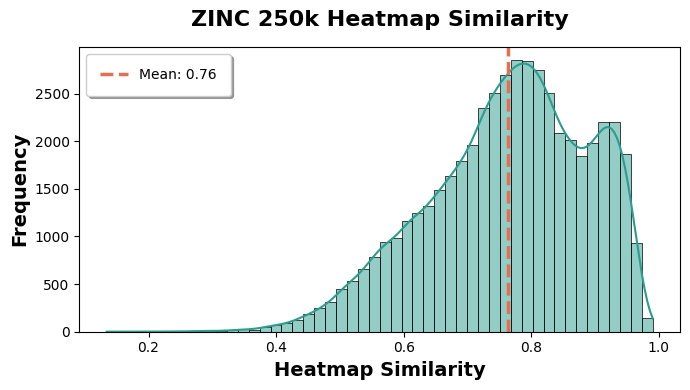

In [81]:
plt.figure(figsize=(7, 4))
ax = sns.histplot(
    data=similarity_arr,
    bins=50, 
    kde=True, 
    color="#2A9D8F",
    edgecolor="black",
    linewidth=0.5
)

mean_val = np.mean(similarity_arr)

plt.axvline(mean_val, color='#E76F51', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_val:.2f}')

plt.title('ZINC 250k Heatmap Similarity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Heatmap Similarity', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.show()

## Ranking

### SangsterLogP

In [129]:
crippen_ranks_arr = []
ig_ranks_arr = []
crippen_percentiles_arr = []
ig_percentiles_arr = []

for crippen, ig in tqdm(zip(collapsed_crippen_arr, collapsed_ig_arr), desc="Calculating Crippen vs IG ranks", total=len(collapsed_crippen_arr)):
    crippen_ranks = stats.rankdata(crippen, method='min')
    ig_ranks = stats.rankdata(ig, method='min')
    
    crippen_ranks_arr.append(crippen_ranks)
    ig_ranks_arr.append(ig_ranks)
    
    N = len(crippen)
    c_per = (crippen_ranks - 1) / (N - 1)
    ig_per = (ig_ranks - 1) / (N - 1)
    
    crippen_percentiles_arr.extend(c_per)
    ig_percentiles_arr.extend(ig_per)

Calculating Crippen vs IG ranks: 100%|██████████| 4704/4704 [00:00<00:00, 5083.32it/s]


In [130]:
threshold = 0.2

c_p_arr = np.array(crippen_percentiles_arr)
ig_p_arr = np.array(ig_percentiles_arr)

c_is_top = c_p_arr >= (1.0 - threshold)
c_is_bottom = c_p_arr <= threshold

ig_is_top = ig_p_arr >= (1.0 - threshold)
ig_is_bottom = ig_p_arr <= threshold

top_agreements = np.sum(c_is_top & ig_is_top)
bottom_agreements = np.sum(c_is_bottom & ig_is_bottom)

total_expected_top = np.sum(c_is_top)
total_expected_bottom = np.sum(c_is_bottom)

total_extreme_accuracy = (top_agreements + bottom_agreements) / (total_expected_top + total_expected_bottom)

print(f"Total Extreme Agreement: {total_extreme_accuracy*100:.2f}%")

Total Extreme Agreement: 48.33%


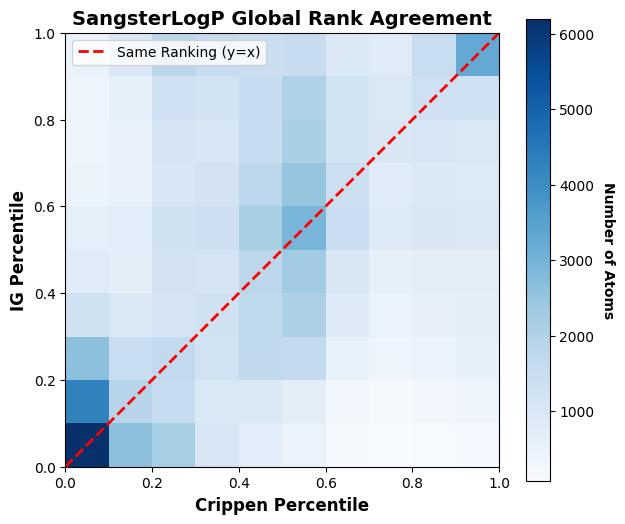

In [131]:
plt.figure(figsize=(7, 6))
h = plt.hist2d(crippen_percentiles_arr, ig_percentiles_arr, bins=10, cmap='Blues', cmin=1)

plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Same Ranking (y=x)')

cbar = plt.colorbar(h[3])
cbar.set_label('Number of Atoms', rotation=270, labelpad=15, fontweight='bold')

plt.title("SangsterLogP Global Rank Agreement", fontsize=14, fontweight='bold')
plt.xlabel("Crippen Percentile", fontsize=12, fontweight='bold')
plt.ylabel("IG Percentile", fontsize=12, fontweight='bold')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_box_aspect(1)
plt.legend(loc='upper left')
plt.show()

### ZINC 250k

In [26]:
crippen_ranks_arr = []
ig_ranks_arr = []
crippen_percentiles_arr = []
ig_percentiles_arr = []

for crippen, ig in tqdm(zip(collapsed_crippen_arr, collapsed_ig_arr), desc="Calculating Crippen vs IG ranks", total=len(collapsed_crippen_arr)):
    crippen_ranks = stats.rankdata(crippen, method='min')
    ig_ranks = stats.rankdata(ig, method='min')
    
    crippen_ranks_arr.append(crippen_ranks)
    ig_ranks_arr.append(ig_ranks)
    
    N = len(crippen)
    c_per = (crippen_ranks - 1) / (N - 1)
    ig_per = (ig_ranks - 1) / (N - 1)
    
    crippen_percentiles_arr.extend(c_per)
    ig_percentiles_arr.extend(ig_per)

Calculating Crippen vs IG ranks: 100%|██████████| 49890/49890 [00:09<00:00, 5369.32it/s]


In [ ]:
threshold = 0.2

c_p_arr = np.array(crippen_percentiles_arr)
ig_p_arr = np.array(ig_percentiles_arr)

c_is_top = c_p_arr >= (1.0 - threshold)
c_is_bottom = c_p_arr <= threshold

ig_is_top = ig_p_arr >= (1.0 - threshold)
ig_is_bottom = ig_p_arr <= threshold

top_agreements = np.sum(c_is_top & ig_is_top)
bottom_agreements = np.sum(c_is_bottom & ig_is_bottom)

total_expected_top = np.sum(c_is_top)
total_expected_bottom = np.sum(c_is_bottom)

total_extreme_accuracy = (top_agreements + bottom_agreements) / (total_expected_top + total_expected_bottom)

print(f"Total Extreme Agreement: {total_extreme_accuracy*100:.2f}%")

Total Extreme Agreement: 62.03%


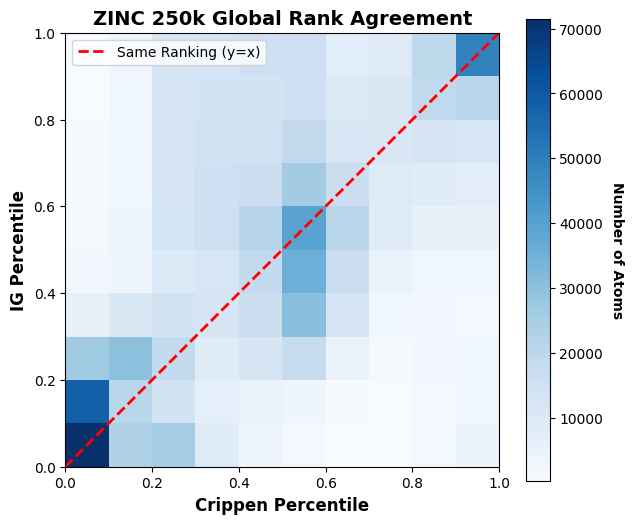

In [101]:
plt.figure(figsize=(7, 6))
h = plt.hist2d(crippen_percentiles_arr, ig_percentiles_arr, bins=10, cmap='Blues', cmin=1)

plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Same Ranking (y=x)')

cbar = plt.colorbar(h[3])
cbar.set_label('Number of Atoms', rotation=270, labelpad=15, fontweight='bold')

plt.title("ZINC 250k Global Rank Agreement", fontsize=14, fontweight='bold')
plt.xlabel("Crippen Percentile", fontsize=12, fontweight='bold')
plt.ylabel("IG Percentile", fontsize=12, fontweight='bold')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_box_aspect(1)
plt.legend(loc='upper left')
plt.show()

In [97]:
pearson_r, _ = stats.pearsonr(crippen_percentiles_arr, ig_percentiles_arr)
pearson_r

np.float64(0.5969465303793742)

## Overlap vs Error

### SangsterLogP

In [134]:
error_arr = np.abs(np.array(pred_logp) - np.array(test_logp))
pearson_r, _ = stats.pearsonr(error_arr, similarity_arr)
spearman_rho, _ = stats.spearmanr(error_arr, similarity_arr)

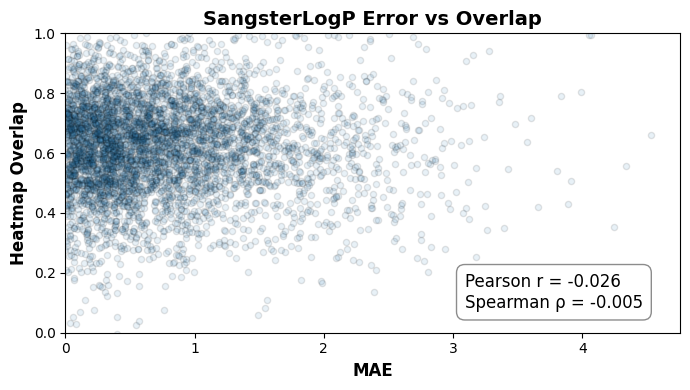

In [135]:
plt.figure(figsize=(7, 4))
plt.scatter(error_arr, similarity_arr, alpha=0.1, edgecolor='k', s=20)

metrics_test = f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_rho:.3f}"
plt.text(0.65, 0.2, metrics_test, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.title("SangsterLogP Error vs Overlap", fontsize=14, fontweight='bold')
plt.xlabel("MAE", fontsize=12, fontweight='bold')
plt.ylabel("Heatmap Overlap", fontsize=12, fontweight='bold')
plt.xlim(0, None)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### ZINC 250k

In [39]:
error_arr = np.abs(np.array(pred_logp) - np.array(test_logp))

In [70]:
pearson_r, _ = stats.pearsonr(error_arr, similarity_arr)
spearman_rho, _ = stats.spearmanr(error_arr, similarity_arr)

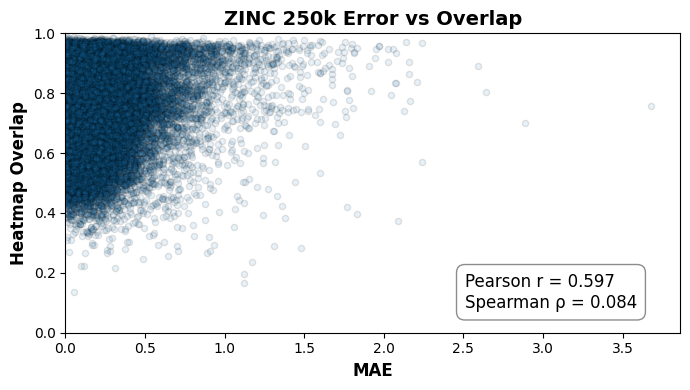

In [100]:
plt.figure(figsize=(7, 4))
plt.scatter(error_arr, similarity_arr, alpha=0.1, edgecolor='k', s=20)

metrics_test = f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_rho:.3f}"
plt.text(0.65, 0.2, metrics_test, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         zorder=5)

plt.title("ZINC 250k Error vs Overlap", fontsize=14, fontweight='bold')
plt.xlabel("MAE", fontsize=12, fontweight='bold')
plt.ylabel("Heatmap Overlap", fontsize=12, fontweight='bold')
plt.xlim(0, None)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## SHAP Variance

In [46]:
shap_attrib_arr = []

for i in range(100):
    shap_attrib = explain_logp_shap(
        model,
        test_data[42],
        global_baseline_node,
        global_baseline_edge,
        ignore_edges = True
    )[0]
    
    shap_attrib_arr.append(shap_attrib)









































































































































































Shapley Value Sampling attribution: 100%|██████████| 4701/4701 [00:21<00:00, 215.22it/s]




































































































































































Shapley Value Sampling attribution: 100%|██████████| 4701/4701 [00:20<00:00, 229.58it/s]




































































































































































Shapley Value Sampling attribution: 100%|██████████| 4701/4701 [00:20<00:00, 230.01it/s]








































































































































































Shapley Value Sampling attribution: 100%|██████████| 4701/4701 [00:21

In [47]:
collapsed_shap_arr = []

for i in tqdm(range(len(shap_attrib_arr)), total=len(shap_attrib_arr)):
    mol_Hs = Chem.AddHs(Chem.MolFromSmiles(test_smiles[42]))
    num_total_atoms = mol_Hs.GetNumAtoms()
    
    collapsed_shap = [0.0] * num_total_atoms
    
    for j, atom in enumerate(mol_Hs.GetAtoms()):
        if atom.GetAtomicNum() == 1:
            neighbor_idx = atom.GetNeighbors()[0].GetIdx()
            collapsed_shap[neighbor_idx] += shap_attrib_arr[i][j]
        else:
            collapsed_shap[j] += shap_attrib_arr[i][j]
            
    heavy_atom_indices = [atom.GetIdx() for atom in mol_Hs.GetAtoms() if atom.GetAtomicNum() != 1]
    final_shap = np.array([collapsed_shap[idx] for idx in heavy_atom_indices])
    
    collapsed_shap_arr.append(final_shap)





100%|██████████| 100/100 [00:00<00:00, 1098.18it/s]


In [48]:
np.savez('collapsed_zinc_shap.npz', *collapsed_shap_arr)

# np_load = np.load('collapsed_zinc_shap.npz')
# collapsed_shap_arr = [np_load[f'arr_{i}'] for i in range(len(np_load.files))]

In [50]:
mean_shap = np.mean(collapsed_shap_arr, axis=0)
var_shap = np.var(collapsed_shap_arr, axis=0)

In [63]:
median_line = Line2D([0], [0], color='orange', linewidth=2, label='SHAP Median')
mean_marker = Line2D([0], [0], color='green', marker='^', linestyle='None', markersize=8, label='SHAP Mean')
crippen_line = Line2D([0], [0], color='cyan', linewidth=2.5, label='Crippen Method')
ig_line = Line2D([0], [0], color='red', linewidth=2.5, label='Integrated Gradients')

x_positions = np.arange(1, 10 + 1)

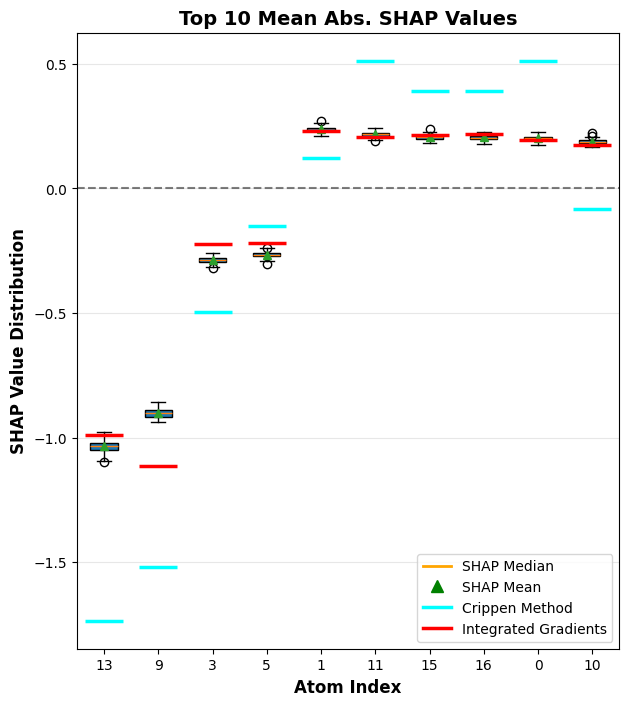

In [64]:
top_indices = np.argsort(np.abs(mean_shap))[-10:][::-1]

plot_data = [np.array(collapsed_shap_arr)[:, idx] for idx in top_indices]
labels = [f"{idx}" for idx in top_indices]

crippen_values = [collapsed_crippen_arr[42][idx] for idx in top_indices]
ig_values = [collapsed_ig_arr[42][idx] for idx in top_indices]

plt.figure(figsize=(7, 8))
plt.boxplot(plot_data, tick_labels=labels, patch_artist=True, showmeans=True)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.hlines(y=crippen_values, xmin=x_positions - 0.35, xmax=x_positions + 0.35, color='cyan', linewidth=2.5, zorder=4, label='Crippen')
plt.hlines(y=ig_values, xmin=x_positions - 0.35, xmax=x_positions + 0.35, color='red', linewidth=2.5, zorder=5, label='Integrated Gradients')

plt.title(f"Top 10 Mean Abs. SHAP Values", fontsize=14, fontweight='bold')
plt.ylabel("SHAP Value Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Atom Index", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.legend(handles=[median_line, mean_marker, crippen_line, ig_line], loc='lower right')
plt.show()

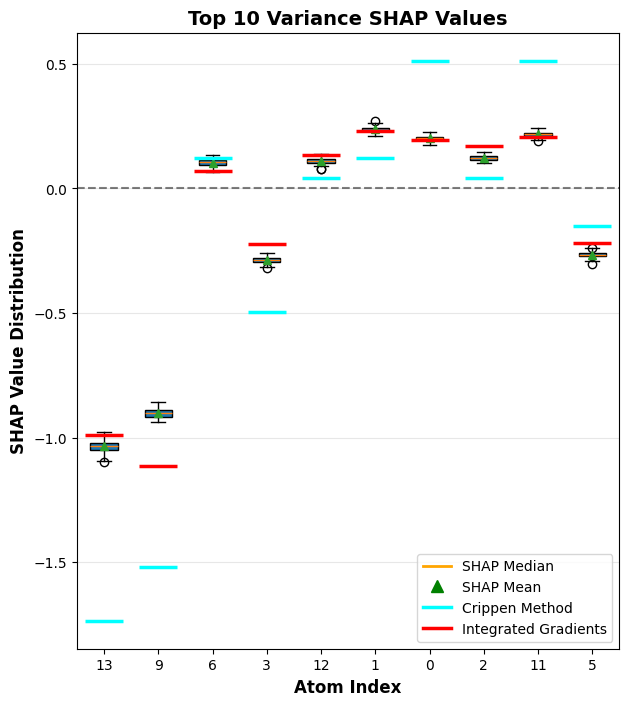

In [65]:
top_indices = np.argsort(np.abs(var_shap))[-10:][::-1]

plot_data = [np.array(collapsed_shap_arr)[:, idx] for idx in top_indices]
labels = [f"{idx}" for idx in top_indices]

crippen_values = [collapsed_crippen_arr[42][idx] for idx in top_indices]
ig_values = [collapsed_ig_arr[42][idx] for idx in top_indices]

plt.figure(figsize=(7, 8))
plt.boxplot(plot_data, tick_labels=labels, patch_artist=True, showmeans=True)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.hlines(y=crippen_values, xmin=x_positions - 0.35, xmax=x_positions + 0.35, color='cyan', linewidth=2.5, zorder=4, label='Crippen')
plt.hlines(y=ig_values, xmin=x_positions - 0.35, xmax=x_positions + 0.35, color='red', linewidth=2.5, zorder=5, label='Integrated Gradients')

plt.title(f"Top 10 Variance SHAP Values", fontsize=14, fontweight='bold')
plt.ylabel("SHAP Value Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Atom Index", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.legend(handles=[median_line, mean_marker, crippen_line, ig_line], loc='lower right')
plt.show()

In [67]:
shap_mask = np.abs(mean_shap) > 0.01
cv_active = var_shap[shap_mask] / np.abs(mean_shap[shap_mask])

print(f"Average CV of active atoms ({np.sum(shap_mask)} / {len(shap_mask)}): {np.mean(cv_active):.4%}")

Average CV of active atoms (18 / 18): 0.0700%


In [66]:
similarity_shap_ig = np.dot(mean_shap, collapsed_ig_arr[42]) / (np.linalg.norm(mean_shap) * np.linalg.norm(collapsed_ig_arr[42]))
similarity_c_ig = np.dot(collapsed_crippen_arr[42], collapsed_ig_arr[42]) / (np.linalg.norm(collapsed_crippen_arr[42]) * np.linalg.norm(collapsed_ig_arr[42]))
similarity_c_shap = np.dot(collapsed_crippen_arr[42], mean_shap) / (np.linalg.norm(collapsed_crippen_arr[42]) * np.linalg.norm(mean_shap))

print(f"Mean SHAP vs IG similarity: {similarity_shap_ig:.4f}")
print(f"Crippen vs IG similarity: {similarity_c_ig:.4f}")
print(f"Crippen vs Mean SHAP similarity: {similarity_c_shap:.4f}")

Mean SHAP vs IG similarity: 0.9897
Crippen vs IG similarity: 0.9496
Crippen vs Mean SHAP similarity: 0.9538
